# 03. 피처 엔지니어링 — 예보 원시값 → 물리 의미가 있는 입력 변수

## 이 노트북의 목적 (Phase 2)

`01_preprocessing.ipynb`가 만든 `train_merged.parquet`에는 기상 예보 원시값이 **800개 컬럼**으로 들어 있다.
그런데 이 값들은 대부분 **바람의 x·y 성분(u, v)** 처럼 "그 자체로는 발전량과 직접 연결되지 않는" 형태다.
예를 들어 `heightAboveGround_10_10u = 3.0`이라는 값만 봐서는 바람이 센지 약한지 알 수 없다
(동시에 `10v = 8.0`이면 실제 풍속은 8.5m/s로 꽤 센 바람이다).

이 노트북은 **원시 예보값을 "발전량과 물리적으로 직결되는 변수"로 바꾸는 작업**을 한다.
크게 6가지를 만든다.

| 순서 | 만드는 것 | 왜 필요한가 (근거) |
|---|---|---|
| 1 | 풍속 `ws`, 풍향 `wd` | 발전량은 바람의 **세기**와 **방향**으로 결정된다. u·v 성분 그대로는 모델이 알기 어렵다 |
| 2 | **허브고도(117m) 풍속** | 터빈 날개는 지상 117m에 있다. 지상 10m 바람이 아니라 그 높이 바람이 발전량을 정한다 (CLAUDE.md 13번) |
| 3 | 공기 밀도 `rho` | 출력 `P = ½·ρ·A·v³`. 같은 풍속이라도 **공기가 무거우면(추우면) 더 많이 발전**한다 |
| 4 | 대기 안정도·난류 | 같은 평균 풍속이라도 바람이 출렁이면 발전량이 달라진다 |
| 5 | 결빙(icing) 위험 | Phase 1에서 **겨울에 "바람은 부는데 출력이 0"인 시간이 몰려 있음**을 확인했다 (`reports/phase1_eda.md` §2-6) |
| 6 | 파워커브 물리 예측치 | SCADA 실측으로 "풍속 → 출력" 곡선을 배워 두고, 예보 풍속을 넣어 **출력을 물리적으로 미리 계산**한다 |

## Phase 1(EDA)에서 넘어온 발견들 — 이 노트북의 출발점

`reports/phase1_eda.md`에서 확인한 것 중 이 노트북이 직접 반영하는 것:

1. **허브고도에 가까운 예보일수록 실측과 잘 맞는다.** GFS는 10m(0.54) < 80m(0.58) < 100m(0.59), LDAPS는 50m(0.77) > 5m 경계층(0.44). → 117m 외삽 피처를 만들 근거.
2. **최고 상관 격자가 최근접 격자가 아니다.** LDAPS는 grid 13, GFS는 grid 2가 가장 상관이 높았다(최근접은 각각 5/6/12, 5). → "대표 격자 하나"가 아니라 **최근접 격자 + 최고상관 격자 + 전체 격자 집계**를 모두 넣는다.
3. **SCADA 발전량에 센서 이상치가 있다** (정격의 만 배 수준, 부호 반전 쌍). → 파워커브를 학습할 때 반드시 걸러야 한다.
4. **겨울(1·2·12월)에 터빈 정지 의심 시간이 몰려 있다.** → 결빙 피처.

## 지킬 규칙 (누수 방지 — CLAUDE.md 4번)

이 노트북에서 가장 조심해야 할 것은 **"미래 정보를 몰래 끌어오지 않는 것"** 이다. 세 가지를 지킨다.

- **예보값의 lag/lead(앞뒤 시각 값)는 써도 된다.** 이 대회의 예보는 **전날 13:00에 한 번 발표되어 다음날 24시간(01:00~24:00)을 통째로 담고 있다**(`data_available_kst_dtm`로 확인함, 리드타임 12~35시간).
  즉 "내일 15시를 예측할 때 내일 16시의 **예보값**"은 이미 어제 13시에 손에 들어와 있던 정보다. 실측이 아니라 예보이므로 미래 정보가 아니다.
- **SCADA(실측)로 학습하는 것들(풍속 보정식, 파워커브)은 학습 기간에서만 fit** 한다. 그리고 2024년을 홀드아웃 검증에 쓸 것이므로, **fit 기간을 2022-01-01 ~ 2023-12-31로 제한**한다.
  (2024년 SCADA까지 써서 파워커브를 만들면, 2024년 검증 점수가 실제보다 좋게 나와서 우리 자신을 속이게 된다.)
- **train과 test에 완전히 똑같은 함수**를 적용한다. 통계값(회귀계수, 파워커브 표)은 train에서 구한 것을 test에 **그대로 갖다 쓰기만** 한다 (fit은 train, transform만 test).

## 0. 준비 — 라이브러리와 상수

숫자를 코드 안에 그냥 적어두면(매직 넘버) 나중에 그 숫자가 어디서 왔는지 알 수 없다.
그래서 물리 상수·기준값은 전부 이름을 붙여 맨 위에 모아 둔다 (CLAUDE.md 8번 규칙).

In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"   # 한글 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False      # 위 폰트는 마이너스(-) 기호가 깨져서 별도 처리

# ---------- 경로 ----------
DATA_DIR = Path("data")
PROCESSED_DIR = DATA_DIR / "processed"
FIG_DIR = Path("reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ---------- 대회 상수 ----------
TARGET_COLS = ["kpx_group_1", "kpx_group_2", "kpx_group_3"]
# 그룹별 설비용량(1시간 기준 kWh) — src/metric.py와 동일한 값
CAPACITY_KWH = {"kpx_group_1": 21600, "kpx_group_2": 21600, "kpx_group_3": 21000}
# 터빈 1기 정격출력(kWh/h). info.xlsx: VESTAS V126 = 3.6MW, UNISON U136 = 4.2MW
RATED_KWH_PER_TURBINE = {"vestas": 3600.0, "unison": 4200.0}

# ---------- 물리 상수 ----------
HUB_HEIGHT_M = 117.0          # info.xlsx, 전 터빈 공통 허브 높이(m)
LDAPS_H_LOW, LDAPS_H_HIGH = 10.0, 50.0    # LDAPS가 제공하는 두 바람 고도(m)
GFS_H_LOW, GFS_H_HIGH = 10.0, 100.0       # GFS가 제공하는 두 바람 고도(m). 80m도 있으나 외삽 기준은 100m
R_D = 287.05                  # 건조공기 기체상수 [J/(kg·K)]
RHO_STD = 1.225               # 표준 공기 밀도 [kg/m³] (해수면, 15°C). IEC 61400-12-1 기준값
G_ACC = 9.80665               # 중력가속도 [m/s²]
LAPSE_K_PER_M = 0.0065        # 표준 기온감률: 100m 올라갈 때마다 0.65°C 하강 [K/m]
T_MEAS_HEIGHT_M = 2.0         # 예보 기온이 측정된 높이(지상 2m)

# ---------- 멱법칙(power law) 외삽 상수 ----------
# 멱법칙: ws(z2) = ws(z1) * (z2/z1)^alpha.  alpha는 "지표가 얼마나 거친가"를 나타내는 시어지수.
# 바다 위 ≈0.10, 평지 ≈0.14, 숲·산악 ≈0.20~0.30.
ALPHA_MIN, ALPHA_MAX = 0.0, 0.6   # 물리적으로 말이 되는 범위로 자른다(음수 시어·과도 외삽 방지)
ALPHA_DEFAULT = 0.262             # 사전 탐색: LDAPS 10m→50m 시어지수의 중앙값 (산악 거친 지형과 부합)
WS_EPS = 0.5                      # 이보다 약한 바람에서는 log 비율이 불안정해서 alpha를 기본값으로 대체 [m/s]

# ---------- 결빙(icing) 판정 상수 ----------
# 근거: CLAUDE.md 13번(결빙 손실) + reports/phase1_eda.md §2-6 (겨울에 정지 의심 집중)
ICING_T_PEAK_C = -3.0     # 착빙이 가장 잘 생기는 기온대(과냉각 물방울이 가장 많은 온도)
ICING_T_WIDTH_C = 4.0     # 그 기온에서 얼마나 멀어지면 위험이 급감하는지(가우시안 폭)
ICING_RH_LOW, ICING_RH_HIGH = 80.0, 100.0   # 상대습도가 80%→100%로 갈수록 위험 0→1로 증가

# ---------- 누수 방지: SCADA 기반 fit 기간 ----------
# 2024년은 홀드아웃 검증용이므로, SCADA로 배우는 것(풍속 보정식·파워커브)은 2022~2023년만 쓴다.
# (CLAUDE.md 4번 규칙: 검증 기간 정보가 피처에 새어 들어가면 검증 점수를 믿을 수 없다)
FIT_START = pd.Timestamp("2022-01-01 01:00:00")
FIT_END   = pd.Timestamp("2024-01-01 00:00:00")   # 이 시각까지(포함) 학습에 사용

N_LDAPS_GRID, N_GFS_GRID = 16, 9
N_TRAIN_HOURS, N_TEST_HOURS = 26304, 8760

RNG_SEED = 42
np.random.seed(RNG_SEED)

pd.set_option("display.max_columns", 12)
print("준비 완료")

준비 완료


## 1. 전처리 캐시 불러오기

Phase 0에서 저장해 둔 parquet만 읽는다 (원본 CSV를 다시 읽지 않는다 — CLAUDE.md 8번).

- `train_merged.parquet`: 26,304행 × 800열 (기상 예보 + 발전량 라벨)
- `test_merged.parquet`: 8,760행 × 797열 (라벨 3개가 없어서 3열 적다)
- `scada_vestas_hourly.parquet` / `scada_unison_hourly.parquet`: 시간 단위로 합친 터빈 실측치

In [2]:
train_merged = pd.read_parquet(PROCESSED_DIR / "train_merged.parquet")
test_merged = pd.read_parquet(PROCESSED_DIR / "test_merged.parquet")
scada_vestas = pd.read_parquet(PROCESSED_DIR / "scada_vestas_hourly.parquet")
scada_unison = pd.read_parquet(PROCESSED_DIR / "scada_unison_hourly.parquet")

assert len(train_merged) == N_TRAIN_HOURS and len(test_merged) == N_TEST_HOURS

print("train_merged:", train_merged.shape, "|", train_merged["forecast_kst_dtm"].min(), "~", train_merged["forecast_kst_dtm"].max())
print("test_merged :", test_merged.shape, "|", test_merged["forecast_kst_dtm"].min(), "~", test_merged["forecast_kst_dtm"].max())
print("scada_vestas:", scada_vestas.shape, "| scada_unison:", scada_unison.shape)

train_merged: (26304, 800) | 2022-01-01 01:00:00 ~ 2025-01-01 00:00:00
test_merged : (8760, 797) | 2025-01-01 01:00:00 ~ 2026-01-01 00:00:00
scada_vestas: (26304, 38) | scada_unison: (17544, 17)


### 1-1. 예보 리드타임 확인 — "예보값의 앞뒤 시각을 써도 되는가"의 근거

lag/lead 피처(앞·뒤 시각의 예보값)를 쓰려면, 그 값이 **예측 시점에 이미 손에 있었는지**를 확인해야 한다
(CLAUDE.md 4번 누수 규칙).

`data_available_kst_dtm`(그 예보를 실제로 쓸 수 있게 된 시각)과 `forecast_kst_dtm`(예보가 가리키는 시각)의
차이를 **리드타임(lead time)** 이라 부른다. 아래 셀로 확인하면:

- 모든 예보의 공개 시각은 **전날 13:00 딱 하나**다.
- 한 번의 예보 발표가 **24개 시각(다음날 01:00 ~ 그다음날 00:00)** 을 통째로 담고 있다.
- 리드타임은 12 ~ 35시간.

즉 "내일 15시를 예측할 때 내일 16시의 예보값"은 어제 13시에 이미 받아 둔 같은 파일 안에 있다.
**예보값의 lead(미래 시각) 피처는 누수가 아니다.** (실측값의 lead였다면 명백한 누수다.)
동시에 리드타임 자체도 피처가 된다 — 예보는 먼 미래일수록 부정확해지기 때문이다.

In [3]:
for name, df in [("train", train_merged), ("test", test_merged)]:
    lead_h = (df["forecast_kst_dtm"] - df["data_available_kst_dtm"]).dt.total_seconds() / 3600
    n_per_run = df.groupby("data_available_kst_dtm").size().unique()
    print(f"[{name}] 리드타임 {lead_h.min():.0f}~{lead_h.max():.0f}h | "
          f"예보 공개 시각(hour) = {sorted(df['data_available_kst_dtm'].dt.hour.unique())} | "
          f"발표 1회당 예보 시각 개수 = {n_per_run}")

[train] 리드타임 12~35h | 예보 공개 시각(hour) = [np.int32(13)] | 발표 1회당 예보 시각 개수 = [24]
[test] 리드타임 12~35h | 예보 공개 시각(hour) = [np.int32(13)] | 발표 1회당 예보 시각 개수 = [24]


## 2. 대표 격자 정하기

LDAPS는 16개, GFS는 9개 격자(grid)를 준다. 전부 다 쓰면 컬럼이 800개라 모델이 헤맨다.
Phase 1의 두 가지 발견을 합쳐서 **"대표 격자"** 를 고른다.

- **최근접 격자**: 터빈 중심점에서 물리적으로 가장 가까운 격자 (LDAPS 5·6·12, GFS 5)
- **최고상관 격자**: 예보 풍속이 SCADA 실측 풍속과 가장 잘 맞았던 격자 (LDAPS 13, GFS 2) — `reports/phase1_eda.md` §2-8

두 기준이 서로 다르다는 것 자체가 중요한 정보다. 산악 지형에서는 바람이 지형을 타고 흐르기 때문에
"가장 가까운 곳"과 "가장 비슷하게 부는 곳"이 다를 수 있다. 그래서 **둘 다 대표 격자에 넣고**,
추가로 **16개(9개) 격자 전체의 평균·표준편차**도 피처로 만든다(표준편차 = 예보들끼리 의견이 갈리는 정도 = 불확실성).

아래 셀은 최근접 격자를 Phase 1과 똑같은 방법(하버사인 거리)으로 다시 계산해서,
사람이 손으로 적은 숫자가 아니라 **코드가 계산한 값**을 쓰도록 한다.

In [4]:
def dms_to_dd(coord_str: str):
    """
    도-분-초 문자열을 십진수 도(decimal degree)로 바꾼다.

    입력: coord_str — info.xlsx의 '좌표(Google)' 컬럼 값. 예: "37°16'40.0\"N 128°57'06.0\"E"
    출력: (lat, lon) 튜플, 단위는 십진수 도. 남반구(S)/서경(W)은 음수.
    """
    matches = re.findall(r"(\d+)\D+(\d+)\D+([\d.]+)\D*([NSEW])", coord_str)
    parsed = {}
    for deg, minute, sec, hemi in matches:
        dd = float(deg) + float(minute) / 60 + float(sec) / 3600
        if hemi in ("S", "W"):
            dd = -dd
        parsed["lat" if hemi in ("N", "S") else "lon"] = dd
    return parsed["lat"], parsed["lon"]


def haversine_km(lat1, lon1, lat2, lon2):
    """두 위경도 점 사이 거리(km). 지구를 반지름 6371km인 구로 가정하는 하버사인 공식."""
    r = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * r * np.arcsin(np.sqrt(a))


# info.xlsx에서 터빈 좌표를 읽어 그룹별 중심점을 구한다 (헤더가 4행째부터라 header=3)
info = pd.read_excel(DATA_DIR / "info.xlsx", sheet_name="info", header=3)
info.columns = [str(c) for c in info.columns]
coord_col = [c for c in info.columns if "좌표" in c][0]
group_col = [c for c in info.columns if "KPX" in c and "그룹" in c][0]
info["group_id"] = info[group_col].ffill().astype(int)   # 그룹 칸이 호기당 1번만 채워져 있어 앞 값으로 채움
info[["lat", "lon"]] = info[coord_col].apply(lambda s: pd.Series(dms_to_dd(s)))
group_center = info.groupby("group_id")[["lat", "lon"]].mean()

# 격자 좌표는 pivot 때 버렸으므로 원본에서 grid_id/위경도 3개 컬럼만 가볍게 다시 읽는다
ldaps_grid = (pd.read_csv(DATA_DIR / "train" / "ldaps_train.csv", encoding="utf-8-sig",
                          usecols=["grid_id", "latitude", "longitude"])
              .drop_duplicates().sort_values("grid_id").reset_index(drop=True))
gfs_grid = (pd.read_csv(DATA_DIR / "train" / "gfs_train.csv", encoding="utf-8-sig",
                        usecols=["grid_id", "latitude", "longitude"])
            .drop_duplicates().sort_values("grid_id").reset_index(drop=True))

nearest = {}
for name, grid in [("ldaps", ldaps_grid), ("gfs", gfs_grid)]:
    ids = []
    for gid, c in group_center.iterrows():
        d = haversine_km(c["lat"], c["lon"], grid["latitude"], grid["longitude"])
        ids.append(int(grid.loc[d.idxmin(), "grid_id"]))
    nearest[name] = sorted(set(ids))
    print(f"{name} 최근접 격자(그룹1,2,3 순): {ids}")

# 최고상관 격자: reports/phase1_eda.md §2-8에서 SCADA 실측 풍속과 상관이 가장 높았던 격자
BEST_CORR_LDAPS_GRID = 13
BEST_CORR_GFS_GRID = 2

LDAPS_REP_GRIDS = sorted(set(nearest["ldaps"]) | {BEST_CORR_LDAPS_GRID})
GFS_REP_GRIDS = sorted(set(nearest["gfs"]) | {BEST_CORR_GFS_GRID})
# 공기 밀도는 "터빈이 실제로 서 있는 고도의 기압·기온"이 중요하므로 최근접 격자들만 평균해서 쓴다
# (LDAPS 격자별 지형고도 surface_0_h가 868~1001m로 제각각이라, 먼 격자를 섞으면 기압이 왜곡된다)
DENSITY_GRIDS = nearest["ldaps"]

print(f"\nLDAPS 대표 격자: {LDAPS_REP_GRIDS} (최근접 {nearest['ldaps']} + 최고상관 {BEST_CORR_LDAPS_GRID})")
print(f"GFS 대표 격자  : {GFS_REP_GRIDS} (최근접 {nearest['gfs']} + 최고상관 {BEST_CORR_GFS_GRID})")
print(f"공기밀도 계산용 LDAPS 격자: {DENSITY_GRIDS}")

ldaps 최근접 격자(그룹1,2,3 순): [5, 6, 12]
gfs 최근접 격자(그룹1,2,3 순): [5, 5, 5]

LDAPS 대표 격자: [5, 6, 12, 13] (최근접 [5, 6, 12] + 최고상관 13)
GFS 대표 격자  : [2, 5] (최근접 [5] + 최고상관 2)
공기밀도 계산용 LDAPS 격자: [5, 6, 12]


## 3. 바람: u·v 성분 → 풍속·풍향

예보는 바람을 **u(동서 성분)**, **v(남북 성분)** 두 개의 화살표 성분으로 준다.
발전량을 결정하는 것은 화살표의 **길이(풍속)** 와 **방향(풍향)** 이므로 변환이 필요하다.

- 풍속: `ws = sqrt(u² + v²)` — 피타고라스 정리. 단위 m/s.
- 풍향: 기상학에서 풍향은 **"바람이 불어오는 쪽"** 을 북쪽 기준 시계방향 각도로 센다.
  공식은 `wd = atan2(-u, -v)` (도 단위, 0~360). u가 +면 서쪽에서 동쪽으로 부는 바람이므로 불어오는 쪽은 서(270°)다.

풍향을 그냥 각도(0~360)로 모델에 넣으면 **359°와 1°가 아주 먼 값처럼 보이는 문제**가 생긴다(실제로는 2° 차이).
그래서 `sin(wd)`, `cos(wd)` 두 개로 쪼개서 넣는다. 이러면 원 위의 위치로 표현되어 359°와 1°가 가까워진다.

In [5]:
def wind_speed(u, v):
    """바람의 u(동서), v(남북) 성분에서 풍속을 구한다. 단위: 입력 m/s -> 출력 m/s."""
    return np.hypot(u, v)


def wind_dir_deg(u, v):
    """
    바람 성분에서 기상학적 풍향(바람이 '불어오는' 방향)을 구한다.

    입력: u, v — 바람 성분 [m/s]
    출력: 0~360 도. 0/360=북풍(북에서 불어옴), 90=동풍, 180=남풍, 270=서풍.
    공식: wd = degrees(atan2(-u, -v)) mod 360
    """
    return np.degrees(np.arctan2(-u, -v)) % 360.0


def dir_sin_cos(wd_deg):
    """풍향(도)을 sin/cos 두 값으로 인코딩한다. 359°와 1°가 서로 멀어 보이는 문제를 없애기 위함."""
    rad = np.radians(wd_deg)
    return np.sin(rad), np.cos(rad)


# 눈으로 확인: 정북에서 불어오는 바람(v=-1, u=0)은 풍향 0도여야 한다
for u, v, expect in [(0, -1, "북 0°"), (-1, 0, "동 90°"), (0, 1, "남 180°"), (1, 0, "서 270°")]:
    print(f"u={u:>3}, v={v:>3} -> ws={wind_speed(u, v):.1f} m/s, wd={wind_dir_deg(u, v):6.1f}°  (기대: {expect})")

u=  0, v= -1 -> ws=1.0 m/s, wd=   0.0°  (기대: 북 0°)
u= -1, v=  0 -> ws=1.0 m/s, wd=  90.0°  (기대: 동 90°)
u=  0, v=  1 -> ws=1.0 m/s, wd= 180.0°  (기대: 남 180°)
u=  1, v=  0 -> ws=1.0 m/s, wd= 270.0°  (기대: 서 270°)


## 4. 허브고도(117m) 풍속 외삽 — 이 노트북의 핵심 피처

### 4-1. 왜 필요한가

터빈 날개의 중심(허브)은 **지상 117m**에 있다. 그런데 예보가 주는 바람은 그 높이가 아니다.

- LDAPS: 지상 **10m**, 지상 **50m**
- GFS: 지상 **10m**, **80m**, **100m**

땅에 가까울수록 마찰 때문에 바람이 느려진다. 그래서 10m 바람만 쓰면 실제 날개가 맞는 바람을 과소평가한다.
발전량은 풍속의 **세제곱**에 비례하므로(`P = ½ρAv³`), 풍속을 10% 틀리면 발전량은 33% 틀린다. 높이 보정은 필수다.

### 4-2. 멱법칙(power law)

높이에 따른 풍속 변화를 나타내는 표준 공식이다.

$$ ws(z_2) = ws(z_1) \times \left(\frac{z_2}{z_1}\right)^{\alpha} $$

- `α`(시어지수, shear exponent): 지표가 거칠수록 크다. 바다 ≈0.10, 평지 ≈0.14, 숲·산악 ≈0.20~0.30.
- 우리는 α를 **책에서 가져오지 않고 예보 데이터에서 직접 계산**한다. 두 높이의 풍속을 알고 있으므로 역산할 수 있다:

$$ \alpha = \frac{\ln(ws_{50} / ws_{10})}{\ln(50/10)} $$

이렇게 시각마다 α가 달라진다는 점이 중요하다. **α는 그 시각의 대기 안정도를 담고 있는 피처**이기도 하다
(밤에 공기가 안정되면 위아래가 잘 안 섞여서 α가 커지고, 낮에 대류가 활발하면 α가 작아진다).

### 4-3. LDAPS의 50m 바람을 다루는 법 — 반드시 짚고 넘어갈 함정

LDAPS 50m 바람 컬럼은 `50MUmax`, `50MUmin`, `50MVmax`, `50MVmin` 네 개다.
이름만 보면 "그 시간의 최대 풍속과 최소 풍속"처럼 보이지만, **실제로는 u 성분과 v 성분 각각의 최댓값·최솟값**이다.
데이터로 확인했다: `50MUmax >= 50MUmin`이 **100% 성립**한다(성분별 max/min이므로 당연). 반면 이걸 풍속으로 바꾸면
`hypot(Umax, Vmax) >= hypot(Umin, Vmin)`은 **73%만 성립**한다 — 즉 "최대 성분끼리 묶은 것"은 풍속의 최댓값이 아니다.

따라서:

- `hypot(Umax, Vmax)`를 "50m 풍속"으로 쓰면 **항상 과대평가**된다. Phase 1에서 이 값이 SCADA보다 평균 +1~2.25m/s 높게 나온 이유가 이것이다.
- 올바른 평균 근사는 **성분별 중간값**을 먼저 만들고 나서 풍속을 구하는 것이다:
  `u50 = (Umax+Umin)/2`, `v50 = (Vmax+Vmin)/2` → `ws50 = hypot(u50, v50)`.
- 덤으로 `hypot(Umax-Umin, Vmax-Vmin)`은 **그 1시간 동안 바람 벡터가 얼마나 출렁였는지(변동폭)** 를 나타낸다.
  이건 버릴 값이 아니라 **난류 강도 피처**로 쓴다. 난류가 세면 같은 평균 풍속이라도 발전 효율이 떨어진다.

실제로 확인해 보면 성분 중간값 방식(`ws50`)의 상관계수는 0.840으로, max 방식(0.8405)과 사실상 같으면서
편향은 +2.25m/s에서 **+1.13m/s로 절반**이 된다. 상관은 그대로 두고 편향만 줄였으니 확실한 개선이다.

In [6]:
def power_law_alpha(ws_low, ws_high, z_low, z_high):
    """
    두 높이의 풍속에서 멱법칙 시어지수 alpha를 역산한다.

    공식: alpha = ln(ws_high/ws_low) / ln(z_high/z_low)
    입력:
        ws_low, ws_high : 낮은 높이/높은 높이의 풍속 [m/s], 같은 길이의 배열
        z_low, z_high   : 각 풍속의 측정 높이 [m]
    출력:
        alpha 배열 (무차원). 아래 두 경우는 ALPHA_DEFAULT로 대체한다:
        - 바람이 너무 약해(< WS_EPS) log 비율이 수치적으로 불안정한 경우
        - 계산 결과가 NaN/inf인 경우
        마지막으로 [ALPHA_MIN, ALPHA_MAX]로 잘라 물리적으로 말이 안 되는 외삽을 막는다.
    """
    with np.errstate(divide="ignore", invalid="ignore"):
        alpha = np.log(ws_high / ws_low) / np.log(z_high / z_low)
    ok = (ws_low > WS_EPS) & (ws_high > WS_EPS) & np.isfinite(alpha)
    alpha = np.where(ok, alpha, ALPHA_DEFAULT)
    return np.clip(alpha, ALPHA_MIN, ALPHA_MAX)


def extrapolate_to_hub(ws_ref, z_ref, alpha):
    """
    기준 높이의 풍속을 허브 높이(117m)로 멱법칙 외삽한다.

    공식: ws_hub = ws_ref * (HUB_HEIGHT_M / z_ref)^alpha
    입력: ws_ref [m/s], z_ref [m], alpha (무차원)
    출력: 허브 높이 풍속 [m/s]
    주의: 외삽 배율은 z_ref가 허브에 가까울수록 1에 가까워 안전하다.
          그래서 LDAPS는 10m가 아니라 50m를, GFS는 100m를 기준으로 삼는다.
    """
    return ws_ref * (HUB_HEIGHT_M / z_ref) ** alpha


# 외삽 배율이 얼마나 되는지 확인 (배율이 클수록 alpha 오차에 민감해진다)
for z_ref, label in [(10.0, "LDAPS 10m"), (50.0, "LDAPS 50m"), (100.0, "GFS 100m")]:
    lo = (HUB_HEIGHT_M / z_ref) ** ALPHA_MIN
    hi = (HUB_HEIGHT_M / z_ref) ** ALPHA_MAX
    mid = (HUB_HEIGHT_M / z_ref) ** ALPHA_DEFAULT
    print(f"{label:>12} -> 117m 외삽 배율: alpha={ALPHA_DEFAULT} 일 때 x{mid:.3f} (범위 x{lo:.3f}~x{hi:.3f})")
print("\n→ 10m를 기준으로 외삽하면 배율이 크고 alpha 오차가 증폭된다. 허브에 가까운 높이(50m/100m)를 기준으로 쓴다.")

   LDAPS 10m -> 117m 외삽 배율: alpha=0.262 일 때 x1.905 (범위 x1.000~x4.374)
   LDAPS 50m -> 117m 외삽 배율: alpha=0.262 일 때 x1.249 (범위 x1.000~x1.665)
    GFS 100m -> 117m 외삽 배율: alpha=0.262 일 때 x1.042 (범위 x1.000~x1.099)

→ 10m를 기준으로 외삽하면 배율이 크고 alpha 오차가 증폭된다. 허브에 가까운 높이(50m/100m)를 기준으로 쓴다.


### 4-4. 격자 하나에서 바람 관련 값을 모두 뽑는 함수

LDAPS와 GFS는 제공 변수가 달라서 함수를 따로 만든다. 두 함수 모두 **격자 번호 하나**를 받아
그 격자의 바람 관련 파생값들을 딕셔너리로 돌려준다.

**LDAPS 격자 하나에서 뽑는 값 (6개)**

| 이름 | 의미 | 계산식 |
|---|---|---|
| `ws10` | 지상 10m 풍속 [m/s] | `hypot(10u, 10v)` |
| `ws50` | 지상 50m 평균 풍속 [m/s] | 성분 중간값으로 먼저 평균 벡터를 만든 뒤 `hypot` |
| `ws50_range` | 1시간 동안 바람 벡터의 변동폭 [m/s] | `hypot(Umax-Umin, Vmax-Vmin)` — 난류 강도 프록시 |
| `alpha` | 시어지수 (10m→50m) | `ln(ws50/ws10)/ln(5)` |
| `ws117` | 허브고도 풍속 [m/s] | `ws50 * (117/50)^alpha` |
| `wd50` | 50m 풍향 [deg] | `atan2(-u50, -v50)` |

**GFS 격자 하나에서 뽑는 값 (10개)**: `ws10`, `ws80`, `ws100`, `alpha`(10m→100m), `ws117`, `wd100`,
`gust`(순간최대풍), `ws_pbl`(경계층 대표 바람), `ws850`/`ws700`/`ws500`(상층 850·700·500hPa 바람 — 산 위를 지나는 큰 흐름).

In [7]:
def ldaps_grid_wind(df: pd.DataFrame, g: int) -> dict:
    """
    LDAPS 격자 g의 바람 파생값을 계산한다.

    입력: df — ldaps_g{g}_* 컬럼을 가진 wide DataFrame, g — 격자 번호(1~16)
    출력: {이름: numpy 배열} 딕셔너리. 길이는 len(df).
    핵심 주의: 50MUmax/50MUmin은 '풍속'의 최대/최소가 아니라 'u 성분'의 최대/최소다.
               그래서 성분별로 중간값을 먼저 만든 뒤에 풍속을 구해야 평균 풍속의 올바른 근사가 된다.
    """
    p = f"ldaps_g{g}_"
    u10 = df[p + "heightAboveGround_10_10u"].to_numpy()
    v10 = df[p + "heightAboveGround_10_10v"].to_numpy()
    u_max = df[p + "heightAboveGround_50_50MUmax"].to_numpy()
    u_min = df[p + "heightAboveGround_50_50MUmin"].to_numpy()
    v_max = df[p + "heightAboveGround_50_50MVmax"].to_numpy()
    v_min = df[p + "heightAboveGround_50_50MVmin"].to_numpy()

    # 성분 중간값 = 그 1시간의 평균 바람 벡터에 대한 근사
    u50 = (u_max + u_min) / 2.0
    v50 = (v_max + v_min) / 2.0

    ws10 = wind_speed(u10, v10)
    ws50 = wind_speed(u50, v50)
    # 성분 변동폭의 크기 = 1시간 동안 바람 벡터가 흔들린 정도(난류·돌풍 프록시)
    ws50_range = wind_speed(u_max - u_min, v_max - v_min)

    alpha = power_law_alpha(ws10, ws50, LDAPS_H_LOW, LDAPS_H_HIGH)
    ws117 = extrapolate_to_hub(ws50, LDAPS_H_HIGH, alpha)
    wd50 = wind_dir_deg(u50, v50)

    wd10 = wind_dir_deg(u10, v10)   # 풍향 시어(veer) 계산용 -- 아래 v2 피처에서 사용

    return {"ws10": ws10, "ws50": ws50, "ws50_range": ws50_range,
            "alpha": alpha, "ws117": ws117, "wd50": wd50, "wd10": wd10}


def gfs_grid_wind(df: pd.DataFrame, g: int) -> dict:
    """
    GFS 격자 g의 바람 파생값을 계산한다.

    입력: df — gfs_g{g}_* 컬럼을 가진 wide DataFrame, g — 격자 번호(1~9)
    출력: {이름: numpy 배열} 딕셔너리.
    GFS는 10m/80m/100m 세 높이를 주므로 100m를 기준으로 117m까지만 살짝 외삽한다(배율 ≈1.04).
    상층(850/700/500hPa) 바람은 '산 위를 지나가는 큰 규모의 흐름'이라 지형에 덜 휘둘리는 정보다.
    """
    p = f"gfs_g{g}_"
    ws10 = wind_speed(df[p + "heightAboveGround_10_10u"].to_numpy(), df[p + "heightAboveGround_10_10v"].to_numpy())
    ws80 = wind_speed(df[p + "heightAboveGround_80_u"].to_numpy(), df[p + "heightAboveGround_80_v"].to_numpy())
    u100 = df[p + "heightAboveGround_100_100u"].to_numpy()
    v100 = df[p + "heightAboveGround_100_100v"].to_numpy()
    ws100 = wind_speed(u100, v100)

    alpha = power_law_alpha(ws10, ws100, GFS_H_LOW, GFS_H_HIGH)
    ws117 = extrapolate_to_hub(ws100, GFS_H_HIGH, alpha)
    wd100 = wind_dir_deg(u100, v100)

    u850, v850 = df[p + "isobaricInhPa_850_u"].to_numpy(), df[p + "isobaricInhPa_850_v"].to_numpy()

    return {
        "ws10": ws10, "ws80": ws80, "ws100": ws100, "alpha": alpha, "ws117": ws117, "wd100": wd100,
        "wd10": wind_dir_deg(df[p + "heightAboveGround_10_10u"].to_numpy(),
                             df[p + "heightAboveGround_10_10v"].to_numpy()),   # veer 계산용
        "wd850": wind_dir_deg(u850, v850),                                     # veer 계산용
        "gust": df[p + "surface_0_gust"].to_numpy(),                       # 순간최대풍속 [m/s]
        "ws_pbl": wind_speed(df[p + "planetaryBoundaryLayer_0_u"].to_numpy(),
                             df[p + "planetaryBoundaryLayer_0_v"].to_numpy()),
        "ws850": wind_speed(u850, v850),
        "ws700": wind_speed(df[p + "isobaricInhPa_700_u"].to_numpy(), df[p + "isobaricInhPa_700_v"].to_numpy()),
        "ws500": wind_speed(df[p + "isobaricInhPa_500_u"].to_numpy(), df[p + "isobaricInhPa_500_v"].to_numpy()),
    }


# 확인: 대표 격자 하나만 돌려보고 값 범위가 상식적인지 본다
_probe = ldaps_grid_wind(train_merged, BEST_CORR_LDAPS_GRID)
print(f"LDAPS grid {BEST_CORR_LDAPS_GRID}:")
for k, v in _probe.items():
    print(f"  {k:>10}: 평균 {v.mean():7.3f}, 최소 {v.min():7.3f}, 최대 {v.max():7.3f}")
_probe_g = gfs_grid_wind(train_merged, BEST_CORR_GFS_GRID)
print(f"\nGFS grid {BEST_CORR_GFS_GRID}:")
for k, v in _probe_g.items():
    print(f"  {k:>10}: 평균 {v.mean():7.3f}, 최소 {v.min():7.3f}, 최대 {v.max():7.3f}")

LDAPS grid 13:
        ws10: 평균   5.239, 최소   0.035, 최대  18.164
        ws50: 평균   7.901, 최소   0.018, 최대  28.408
  ws50_range: 평균   1.639, 최소   0.118, 최대  19.716
       alpha: 평균   0.243, 최소   0.000, 최대   0.600
       ws117: 평균   9.907, 최소   0.023, 최대  36.069
        wd50: 평균 210.138, 최소   0.003, 최대 359.914
        wd10: 평균 211.011, 최소   0.038, 최대 359.977

GFS grid 2:
        ws10: 평균   2.596, 최소   0.005, 최대  14.905
        ws80: 평균   3.802, 최소   0.040, 최대  26.121
       ws100: 평균   3.963, 최소   0.027, 최대  27.640
       alpha: 평균   0.163, 최소   0.000, 최대   0.600
       ws117: 평균   4.090, 최소   0.028, 최대  28.999
       wd100: 평균 208.749, 최소   0.029, 최대 359.970
        wd10: 평균 207.569, 최소   0.006, 최대 359.994
       wd850: 평균 231.087, 최소   0.010, 최대 359.983
        gust: 평균   4.647, 최소   0.200, 최대  30.502
      ws_pbl: 평균   4.649, 최소   0.029, 최대  41.094
       ws850: 평균   8.378, 최소   0.039, 최대  46.763
       ws700: 평균  11.577, 최소   0.097, 최대  46.473
       ws500: 평균  19.537, 최소   0.082, 최대 

### 4-5. 외삽 결과 확인 (그림)

alpha 분포와, 높이별 풍속(10m → 50m → 117m)이 실제로 단조 증가하는지 눈으로 확인한다.
동시에 SCADA 실측 풍속(나셀 풍속계, 117m)과도 겹쳐 그려서 **편향이 어느 정도인지** 본다.

**미리 알아둘 것 — 나셀 풍속계는 실제보다 낮게 읽는다.**
SCADA의 `ws`는 터빈 **날개 뒤쪽(나셀 위)** 에 달린 풍속계 값이다. 날개가 바람에서 에너지를 뺏은 뒤의 바람을 재기 때문에,
자유류(방해받지 않은 바람)보다 구조적으로 느리게 측정된다. 따라서 "예보를 SCADA 풍속에 맞추는 것"이 곧
"물리적으로 정확한 허브 풍속"을 뜻하지는 않는다.

그래서 이 노트북은 **α를 SCADA에 억지로 맞추지 않는다.** α는 예보 내부의 두 높이만으로 구하고(순수 물리),
"예보 → 실측 나셀 풍속"의 차이는 **6절에서 따로 선형 보정식**으로 배운다. 역할을 분리하는 것이 핵심이다.

In [8]:
# 그룹별 SCADA 실측 평균 풍속(나셀 풍속계, 허브고도 117m) 시계열을 만든다.
GROUP_TURBINES = {
    "kpx_group_1": ("vestas", [f"vestas_wtg{i:02d}" for i in range(1, 7)]),
    "kpx_group_2": ("vestas", [f"vestas_wtg{i:02d}" for i in range(7, 13)]),
    "kpx_group_3": ("unison", [f"unison_wtg{i:02d}" for i in range(1, 6)]),
}

def build_scada_group_frame() -> pd.DataFrame:
    """
    그룹별 SCADA 실측치를 시간 단위 한 표로 모은다.

    출력 컬럼:
        forecast_kst_dtm      : 시각(구간 종료 시각). 라벨/예보와 같은 기준.
        scada_ws_{group}      : 그룹 내 터빈들의 나셀 풍속 평균 [m/s]
        scada_power_{group}   : 그룹 내 터빈 발전량 합계 [kWh]
        scada_valid_{group}   : 그 시간의 SCADA를 믿어도 되는지 (bool)
    'valid' 판정 (근거: reports/phase1_eda.md §2-5에서 발견한 센서 이상치):
        - 그 시간에 10분 샘플이 6개 다 있어야 한다 (n_samples == 6)
        - 그룹 내 모든 터빈의 발전량이 |power| <= 정격 x 1.05 여야 한다
          (정격의 만 배가 넘는 부호 반전 쌍 이상치를 제거)
    """
    frames = []
    for src, hourly in [("vestas", scada_vestas), ("unison", scada_unison)]:
        frames.append(hourly.set_index("kst_dtm"))
    ves_i, uni_i = frames

    out = pd.DataFrame(index=ves_i.index.union(uni_i.index))
    out.index.name = "forecast_kst_dtm"
    for group, (src, tids) in GROUP_TURBINES.items():
        h = ves_i if src == "vestas" else uni_i
        rated = RATED_KWH_PER_TURBINE[src]
        pw = h[[f"{t}_power_kwh" for t in tids]]
        wsm = h[[f"{t}_ws_mean" for t in tids]]

        # 이상치 판정: 한 터빈이라도 정격의 105%를 넘는 값을 보이면 그 시간 전체를 못 믿는다
        outlier = (pw.abs() > rated * 1.05).any(axis=1)
        complete = h["n_samples"] == 6
        valid = complete & ~outlier & pw.notna().all(axis=1) & wsm.notna().all(axis=1)

        out[f"scada_ws_{group}"] = wsm.mean(axis=1).reindex(out.index)
        out[f"scada_power_{group}"] = pw.sum(axis=1).reindex(out.index)
        out[f"scada_valid_{group}"] = valid.reindex(out.index).fillna(False)
    return out.reset_index()


scada_group = build_scada_group_frame()
print("scada_group:", scada_group.shape)
for group in TARGET_COLS:
    v = scada_group[f"scada_valid_{group}"]
    print(f"  {group}: 유효 시간 {v.sum():,} / {len(v):,} ({v.mean()*100:.1f}%)")
scada_group.head(3)

scada_group: (26304, 10)
  kpx_group_1: 유효 시간 26,134 / 26,304 (99.4%)
  kpx_group_2: 유효 시간 26,139 / 26,304 (99.4%)
  kpx_group_3: 유효 시간 16,850 / 26,304 (64.1%)


,forecast_kst_dtm,scada_ws_kpx_group_1,scada_power_kpx_group_1,scada_valid_kpx_group_1,scada_ws_kpx_group_2,scada_power_kpx_group_2,scada_valid_kpx_group_2,scada_ws_kpx_group_3,scada_power_kpx_group_3,scada_valid_kpx_group_3
0,2022-01-01 01:00:00,8.233333,2005,False,7.800000,1536,False,NaN,NaN,False
1,2022-01-01 02:00:00,8.555556,13090,True,7.944444,10410,True,NaN,NaN,False
2,2022-01-01 03:00:00,8.280556,12188,True,8.211111,10880,True,NaN,NaN,False


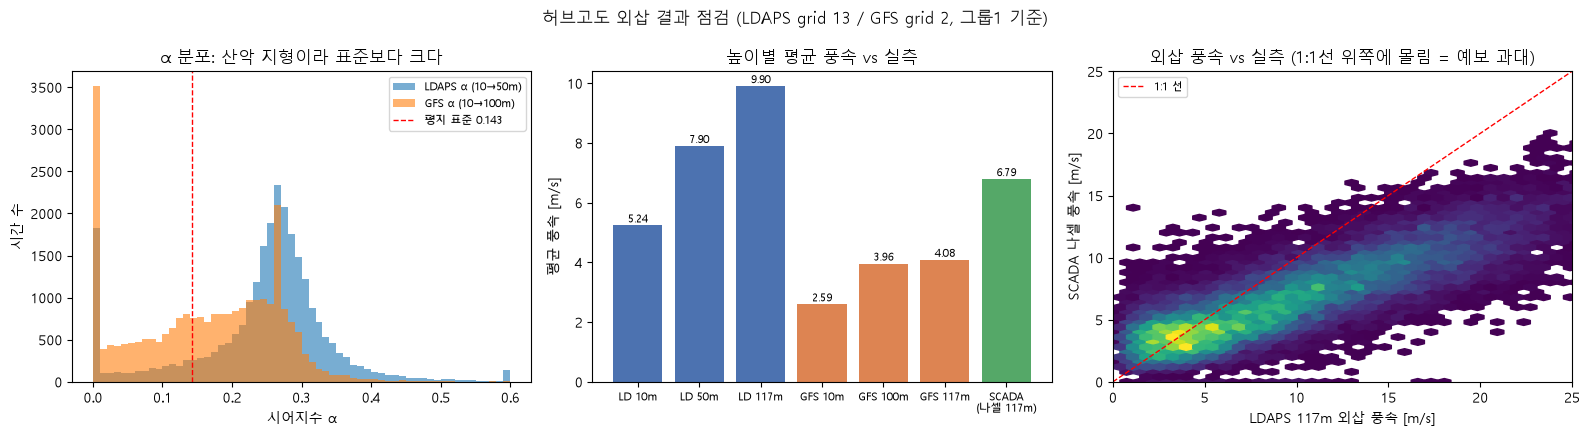

  ldaps_ws50: SCADA 대비 편향 +1.110 m/s, 상관 0.8410
 ldaps_ws117: SCADA 대비 편향 +3.115 m/s, 상관 0.8361
   gfs_ws100: SCADA 대비 편향 -2.830 m/s, 상관 0.7268
   gfs_ws117: SCADA 대비 편향 -2.703 m/s, 상관 0.7268


In [9]:
# 대표 격자에서 계산한 alpha·풍속의 분포와, SCADA 실측 풍속과의 관계를 그림으로 확인
_ld = ldaps_grid_wind(train_merged, BEST_CORR_LDAPS_GRID)
_gf = gfs_grid_wind(train_merged, BEST_CORR_GFS_GRID)
_cmp = pd.DataFrame({
    "forecast_kst_dtm": train_merged["forecast_kst_dtm"],
    "ldaps_ws10": _ld["ws10"], "ldaps_ws50": _ld["ws50"], "ldaps_ws117": _ld["ws117"], "ldaps_alpha": _ld["alpha"],
    "gfs_ws10": _gf["ws10"], "gfs_ws100": _gf["ws100"], "gfs_ws117": _gf["ws117"], "gfs_alpha": _gf["alpha"],
}).merge(scada_group[["forecast_kst_dtm", "scada_ws_kpx_group_1", "scada_valid_kpx_group_1"]], on="forecast_kst_dtm", how="left")
_ok = _cmp["scada_valid_kpx_group_1"].fillna(False)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
axes[0].hist(_cmp["ldaps_alpha"], bins=60, alpha=0.6, label=f"LDAPS α (10→50m)")
axes[0].hist(_cmp["gfs_alpha"], bins=60, alpha=0.6, label=f"GFS α (10→100m)")
axes[0].axvline(0.143, color="red", ls="--", lw=1, label="평지 표준 0.143")
axes[0].set_xlabel("시어지수 α"); axes[0].set_ylabel("시간 수"); axes[0].legend(fontsize=8)
axes[0].set_title("α 분포: 산악 지형이라 표준보다 크다")

heights = ["ldaps_ws10", "ldaps_ws50", "ldaps_ws117", "gfs_ws10", "gfs_ws100", "gfs_ws117"]
means = [_cmp.loc[_ok, c].mean() for c in heights] + [_cmp.loc[_ok, "scada_ws_kpx_group_1"].mean()]
axes[1].bar(range(len(means)), means, color=["#4C72B0"]*3 + ["#DD8452"]*3 + ["#55A868"])
axes[1].set_xticks(range(len(means)))
axes[1].set_xticklabels(["LD 10m", "LD 50m", "LD 117m", "GFS 10m", "GFS 100m", "GFS 117m", "SCADA\n(나셀 117m)"], fontsize=8)
axes[1].set_ylabel("평균 풍속 [m/s]"); axes[1].set_title("높이별 평균 풍속 vs 실측")
for i, m in enumerate(means):
    axes[1].text(i, m + 0.1, f"{m:.2f}", ha="center", fontsize=8)

axes[2].hexbin(_cmp.loc[_ok, "ldaps_ws117"], _cmp.loc[_ok, "scada_ws_kpx_group_1"], gridsize=50, mincnt=1, cmap="viridis")
lim = [0, 25]
axes[2].plot(lim, lim, "r--", lw=1, label="1:1 선")
axes[2].set_xlim(lim); axes[2].set_ylim(lim)
axes[2].set_xlabel("LDAPS 117m 외삽 풍속 [m/s]"); axes[2].set_ylabel("SCADA 나셀 풍속 [m/s]")
axes[2].legend(fontsize=8); axes[2].set_title("외삽 풍속 vs 실측 (1:1선 위쪽에 몰림 = 예보 과대)")

fig.suptitle("허브고도 외삽 결과 점검 (LDAPS grid 13 / GFS grid 2, 그룹1 기준)")
fig.tight_layout()
fig.savefig(FIG_DIR / "phase2_hub_extrapolation.png", dpi=120)
plt.show()

for c in ["ldaps_ws50", "ldaps_ws117", "gfs_ws100", "gfs_ws117"]:
    bias = (_cmp.loc[_ok, c] - _cmp.loc[_ok, "scada_ws_kpx_group_1"]).mean()
    corr = _cmp.loc[_ok, c].corr(_cmp.loc[_ok, "scada_ws_kpx_group_1"])
    print(f"{c:>12}: SCADA 대비 편향 {bias:+.3f} m/s, 상관 {corr:.4f}")

## 5. 나머지 물리 피처 — 공기 밀도, 안정도, 결빙, 시간

### 5-1. 공기 밀도 (출력 ∝ 밀도)

풍력 출력 공식 `P = ½·ρ·A·v³`에서 `ρ`(공기 밀도)는 풍속만큼은 아니어도 **1차 비례**한다.
겨울에 -10°C일 때와 여름에 30°C일 때 밀도는 약 **15% 차이**가 난다 — 같은 바람이 불어도 발전량이 15% 다르다는 뜻이다.
태백은 해발 약 900~1000m라 기압이 낮아(≈900hPa) 밀도가 표준보다 애초에 낮다.

**이상기체 상태방정식**으로 계산한다:

$$ \rho = \frac{p}{R_d \cdot T_v}, \qquad T_v = T (1 + 0.608\,q) $$

- `p`: 기압 [Pa], `T`: 기온 [K], `q`: 비습(공기 1kg에 든 수증기 kg) [kg/kg]
- `R_d = 287.05` J/(kg·K): 건조공기 기체상수
- `T_v`(가온도, virtual temperature): 수증기가 섞이면 공기가 **가벼워지는** 효과를 기온을 살짝 올려서 흉내내는 보정값.
  습한 공기가 마른 공기보다 가볍다는 사실이 직관에 반하지만, 수증기 분자(H₂O, 18)가 질소·산소(28·32)보다 가볍기 때문이다.

예보의 기압·기온은 **지상 2m**의 값이므로, 허브(117m)까지 올린다:

- 기온: `T_hub = T_2m - 0.0065 × (117 - 2)` (표준 기온감률, 100m마다 0.65°C 하강)
- 기압: `p_hub = p_surface × exp(-g·Δz / (R_d·T_v))` (정역학 평형; 높이 올라가면 기압이 지수적으로 감소)

마지막으로 **밀도 보정 풍속**을 만든다 (IEC 61400-12-1 국제표준 방식):

$$ ws_{\text{corr}} = ws \times \left(\frac{\rho}{\rho_{std}}\right)^{1/3} $$

세제곱근을 쓰는 이유: 출력은 `ρ·v³`에 비례하므로, 밀도 변화를 "같은 출력을 내는 등가 풍속"으로 환산하면 세제곱근이 된다.
이렇게 하면 **표준 밀도 기준의 파워커브 하나로 모든 계절을 다룰 수 있다.**

In [10]:
def air_density(pressure_pa, temp_k, spec_humidity):
    """
    이상기체 상태방정식으로 공기 밀도를 구한다.

    공식: rho = p / (R_d * T_v),  T_v = T * (1 + 0.608*q)
    입력:
        pressure_pa   : 기압 [Pa]
        temp_k        : 기온 [K]
        spec_humidity : 비습 [kg/kg] (공기 1kg 중 수증기 질량)
    출력: 공기 밀도 [kg/m³]. 태백(해발 ~1000m)에서는 대략 1.05~1.20 범위가 정상.
    """
    t_virtual = temp_k * (1.0 + 0.608 * spec_humidity)
    return pressure_pa / (R_D * t_virtual)


def pressure_at_height(p_surface_pa, temp_k, spec_humidity, dz_m):
    """
    지상 기압을 dz_m 만큼 위의 기압으로 환산한다 (정역학 평형, 등온 가정).

    공식: p(z) = p0 * exp(-g*dz / (R_d*T_v))
    입력: p_surface_pa [Pa], temp_k [K], spec_humidity [kg/kg], dz_m [m]
    출력: 높이 dz_m 지점의 기압 [Pa]
    주의: 117m 정도의 짧은 거리라 등온 가정 오차는 무시할 수준(기압 약 1.3% 감소).
    """
    t_virtual = temp_k * (1.0 + 0.608 * spec_humidity)
    return p_surface_pa * np.exp(-G_ACC * dz_m / (R_D * t_virtual))


def density_corrected_ws(ws, rho):
    """
    공기 밀도를 반영해 '표준 밀도에서 같은 출력을 내는 등가 풍속'으로 바꾼다 (IEC 61400-12-1).

    공식: ws_corr = ws * (rho / RHO_STD)^(1/3)
    입력: ws [m/s], rho [kg/m³]
    출력: 밀도 보정 풍속 [m/s]
    이유: 출력 P ∝ rho * v³ 이므로, rho 변화를 v로 흡수하려면 세제곱근을 취해야 한다.
    """
    return ws * np.cbrt(rho / RHO_STD)


# 눈으로 확인: 태백 조건에서 밀도가 상식적인 범위인지
for t_c, label in [(-10.0, "한겨울 -10°C"), (15.0, "봄가을 15°C"), (30.0, "한여름 30°C")]:
    rho = air_density(90000.0, t_c + 273.15, 0.005)
    print(f"{label:>14}: 기압 900hPa, 비습 0.005 -> rho = {rho:.4f} kg/m³ "
          f"(표준 대비 {(rho/RHO_STD-1)*100:+.1f}%, 등가풍속 배율 x{np.cbrt(rho/RHO_STD):.4f})")

     한겨울 -10°C: 기압 900hPa, 비습 0.005 -> rho = 1.1879 kg/m³ (표준 대비 -3.0%, 등가풍속 배율 x0.9898)
      봄가을 15°C: 기압 900hPa, 비습 0.005 -> rho = 1.0848 kg/m³ (표준 대비 -11.4%, 등가풍속 배율 x0.9603)
      한여름 30°C: 기압 900hPa, 비습 0.005 -> rho = 1.0311 kg/m³ (표준 대비 -15.8%, 등가풍속 배율 x0.9442)


### 5-2. 대기 안정도·난류

같은 평균 풍속이라도 **바람의 질**이 다르면 발전량이 달라진다.

- **경계층 높이 `blh`** (LDAPS `etc_0_blh`, 단위 m): 지면의 영향을 받아 공기가 잘 섞이는 층의 두께.
  낮에 햇볕으로 대류가 일어나면 두꺼워지고(수백~수천 m), 밤에 안정되면 얇아진다(수십 m).
  경계층이 허브 높이(117m)보다 얇으면 터빈 날개가 **경계층 위의 다른 바람**을 맞는다 → 예보 오차가 커지는 조건.
- **환기율 `VRATE`** (GFS, 경계층 두께 × 평균 바람): 대기가 얼마나 잘 섞이는지.
- **시어 `ws117 - ws10`**: 위아래 풍속 차이. 크면 안정, 작으면 잘 섞임.
- **상하층 기온차 `t850 - t500`**: 850hPa(약 1.5km)와 500hPa(약 5.5km)의 기온차. 크면 불안정(대류 발달).
- **돌풍계수 `gust / ws10`**: 순간최대풍이 평균의 몇 배인가. 난류 강도를 직접 나타낸다.
- **`ws50_range`** (4-4절에서 만든 것): 1시간 안에서 바람 벡터가 출렁인 폭.

### 5-3. 결빙(icing) 위험

Phase 1에서 **"바람은 충분한데(≥5m/s) 출력은 정격의 5% 미만"인 시간이 1·2·12월에 몰려 있음**을 확인했다
(`reports/phase1_eda.md` §2-6, 터빈별 2.6~5.96%). 날개에 얼음이 붙으면 날개 모양이 망가져 양력이 줄고,
심하면 안전을 위해 터빈을 멈춘다. 겨울 예측 오차의 주범이다.

착빙은 **과냉각 물방울**(0°C 아래인데 얼지 않은 물방울)이 날개에 부딪혀 얼면서 생긴다. 조건은:

1. 기온이 0°C 근처의 **좁은 구간** — 너무 따뜻하면 물이 안 얼고, 너무 추우면(-15°C 이하) 공기 중 수분이 이미 얼음 결정이라 잘 안 붙는다. 가장 위험한 온도는 약 **-3°C**.
2. **습도가 높다** (구름/안개 속). 상대습도 90% 이상.
3. 강수·착설이 있으면 더 위험.

이걸 0~1 사이 연속 점수로 만든다 (0/1 플래그보다 정보량이 많다):

$$ \text{icing\_score} = \underbrace{\exp\!\left(-\left(\frac{T - (-3)}{4}\right)^2\right)}_{\text{기온 점수: }-3°C\text{에서 1, 멀어지면 0}} \times \underbrace{\text{clip}\!\left(\frac{RH - 80}{20},\,0,\,1\right)}_{\text{습도 점수: }80\%\to 0,\ 100\%\to 1} $$

### 5-4. 시간 인코딩

Phase 1에서 **새벽·야간에 이용률이 높고 낮 12~16시에 낮다**, **겨울과 7월이 높다**는 뚜렷한 패턴을 봤다.
시(hour)와 월(month)은 **주기(cyclic)** 값이다. 23시와 0시는 1시간 차이인데 숫자로는 23이나 떨어져 보인다.
그래서 풍향과 같은 이유로 `sin`/`cos`로 인코딩한다. `lead_h`(예보 리드타임)도 함께 넣는다 — 먼 미래 예보일수록 부정확하다.

In [11]:
def cyclic_encode(values, period):
    """
    주기적인 값(시각, 월, 연중일)을 sin/cos 두 축으로 인코딩한다.

    입력: values — 0부터 period-1 범위의 값, period — 한 바퀴의 크기(24, 12, 365 등)
    출력: (sin 배열, cos 배열)
    이유: 23시와 0시는 실제로 1시간 차이지만 숫자로는 23 차이다. 원 위에 올리면 이웃이 된다.
    """
    ang = 2.0 * np.pi * values / period
    return np.sin(ang), np.cos(ang)


def icing_score(temp_c, rh_pct):
    """
    착빙(결빙) 위험을 0~1 연속 점수로 계산한다.

    입력: temp_c — 허브고도 기온 [°C], rh_pct — 상대습도 [%]
    출력: 0(위험 없음) ~ 1(매우 위험) 점수
    공식: exp(-((T - (-3))/4)^2) * clip((RH-80)/20, 0, 1)
    근거: 과냉각 물방울에 의한 착빙은 -3°C 부근, 고습(구름/안개 속)에서 가장 활발하다.
          CLAUDE.md 13번(결빙 손실) + reports/phase1_eda.md §2-6(겨울 정지 집중).
    주의: LDAPS 상대습도는 과포화를 허용해 110%까지 나오므로 100으로 잘라서 쓴다.
    """
    t_term = np.exp(-(((temp_c - ICING_T_PEAK_C) / ICING_T_WIDTH_C) ** 2))
    rh = np.clip(rh_pct, 0.0, ICING_RH_HIGH)
    rh_term = np.clip((rh - ICING_RH_LOW) / (ICING_RH_HIGH - ICING_RH_LOW), 0.0, 1.0)
    return t_term * rh_term


# 눈으로 확인: 결빙 점수가 상식과 맞는지
for t, rh, note in [(-3, 98, "가장 위험(과냉각 안개)"), (-3, 70, "춥지만 건조"), (5, 98, "습하지만 따뜻"),
                    (-20, 98, "너무 추움"), (0, 92, "위험")]:
    print(f"기온 {t:>4}°C, 습도 {rh:>3}% -> icing_score = {icing_score(np.array([t]), np.array([rh]))[0]:.3f}  ({note})")

기온   -3°C, 습도  98% -> icing_score = 0.900  (가장 위험(과냉각 안개))
기온   -3°C, 습도  70% -> icing_score = 0.000  (춥지만 건조)
기온    5°C, 습도  98% -> icing_score = 0.016  (습하지만 따뜻)
기온  -20°C, 습도  98% -> icing_score = 0.000  (너무 추움)
기온    0°C, 습도  92% -> icing_score = 0.342  (위험)


## 6. 기상 피처 조립 함수

지금까지 만든 조각들을 하나의 함수 `build_weather_features(df)`로 묶는다.
**train과 test에 똑같은 이 함수를 적용**한다 (CLAUDE.md 12번 재현성 규칙 — A방식: 같은 셀 로직으로 둘 다 처리).

이 함수는 **학습된 통계값을 전혀 쓰지 않는다.** 순수하게 그 행의 예보값만으로 계산되는 물리 변환뿐이다.
따라서 train/test 사이에 어떤 정보도 새지 않는다 (SCADA로 배우는 것은 7절에서 따로 붙인다).

만드는 컬럼 묶음:

| 묶음 | 개수(대략) | 설명 |
|---|---:|---|
| 시간 | 7 | hour/month/dayofyear의 sin·cos, 리드타임 |
| LDAPS 대표 격자 | 4격자 × 9 | ws10/ws50/ws117 및 세제곱, 시어, α, 난류폭, 풍향 sin·cos |
| LDAPS 전체 격자 집계 | 7 | ws117의 평균·표준편차·최소·최대 등 (표준편차 = 공간 불확실성) |
| GFS 대표 격자 | 2격자 × 13 | ws10/80/100/117, 상층 바람, 돌풍, 풍향 sin·cos |
| GFS 전체 격자 집계 | 7 | 위와 동일 |
| 소스 불일치 | 3 | LDAPS와 GFS의 117m 풍속 차이 = **두 예보가 의견이 갈리는 정도(불확실성)** |
| 공기 밀도 | 8 | 기온·습도·기압·밀도·밀도보정풍속·ρv³ |
| 안정도 | 7 | 경계층 높이, 환기율, 상하층 기온차, 시어 |
| 결빙 | 8 | 결빙 점수, 강수, 적설, 이슬점차 |

### 알고 넘어갈 두 가지 (나중에 헷갈리지 않도록)

**1. `ws117_sq`, `ws117_cube`는 트리 모델에게는 새 정보가 아니다.**
결정트리는 "이 값이 8보다 큰가?" 같은 **크기 비교**로만 데이터를 자른다. 그런데 `v³`은 `v`가 커지면 반드시 커지는
**단조 변환**이라, `v³ > 512`는 `v > 8`과 완전히 같은 조건이다. 즉 트리에게 `v³`을 따로 주는 건 정보량 0이다.
그래도 넣어 두는 이유는 (a) Phase 3에서 **선형 모델·신경망도 비교**할 예정인데 이들에게는 `v³`이 결정적이고,
(b) `rho × v³`처럼 **다른 변수와 곱해진 항은 단조 변환이 아니라 진짜 새 정보**이기 때문이다.
Phase 3에서 최종 모델이 트리 계열로 정해지면 이 컬럼들을 빼고 성능이 같은지 확인할 것이다.

반면 `pc_pred`를 설비용량으로 나눈 "이용률" 컬럼은 **어떤 모델에게도 정보량 0**이다(상수로 나눈 배율일 뿐).
그래서 만들지 않는다. `v³`(비선형)과 `v/상수`(선형)의 차이가 이 판단의 기준이다.

**2. `lead_h`는 사실상 "몇 시인가"와 같은 값이다.**
이 대회는 예보가 **하루에 딱 한 번(전날 13:00)** 발표되므로 `lead_h = 시각 + 12`로 완전히 결정된다
(00시만 35). 즉 `hour_sin/cos`와 같은 정보다. 다만 `hour_sin/cos`는 원형이고 `lead_h`는 직선형(단조)이라
"예보가 멀수록 부정확하다"는 관계를 트리가 한 번에 자르기 쉬워서 함께 남긴다.

In [12]:
def build_weather_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    기상 예보 wide 표에서 물리 피처를 만든다. train/test에 동일하게 적용한다.

    입력: df — 01_preprocessing.ipynb가 만든 merged 표
              (forecast_kst_dtm, data_available_kst_dtm, ldaps_g*_*, gfs_g*_* 컬럼)
    출력: forecast_kst_dtm + 피처 컬럼들을 가진 DataFrame (행 수·순서는 입력과 동일)

    누수 안전성 (CLAUDE.md 4번):
        - 이 함수는 학습된 계수/통계값을 하나도 쓰지 않는다. 각 행의 예보값만으로 계산된다.
        - 따라서 train에서 fit하고 test에 transform 한다는 개념 자체가 필요 없다.
    """
    out = {"forecast_kst_dtm": df["forecast_kst_dtm"].to_numpy()}
    n = len(df)

    # ---------------------------------------------------------------
    # (1) 시간 피처
    # forecast_kst_dtm은 '구간 종료 시각'이다 (01:00 = 00~01시 발전량). CLAUDE.md 2번.
    # ---------------------------------------------------------------
    dt = df["forecast_kst_dtm"].dt
    hour = dt.hour.to_numpy()
    out["hour_sin"], out["hour_cos"] = cyclic_encode(hour, 24)
    out["month_sin"], out["month_cos"] = cyclic_encode(dt.month.to_numpy() - 1, 12)
    out["doy_sin"], out["doy_cos"] = cyclic_encode(dt.dayofyear.to_numpy() - 1, 365)
    # 예보 리드타임: 예측 시점(전날 13시)에서 몇 시간 뒤를 예보한 값인가. 멀수록 부정확하다.
    out["lead_h"] = (df["forecast_kst_dtm"] - df["data_available_kst_dtm"]).dt.total_seconds().to_numpy() / 3600.0

    # ---------------------------------------------------------------
    # (2) LDAPS: 격자별 바람 -> 대표 격자 상세 + 전체 격자 집계
    # ---------------------------------------------------------------
    ld = {g: ldaps_grid_wind(df, g) for g in range(1, N_LDAPS_GRID + 1)}

    for g in LDAPS_REP_GRIDS:
        w = ld[g]
        out[f"ldaps_g{g}_ws10"] = w["ws10"]
        out[f"ldaps_g{g}_ws50"] = w["ws50"]
        out[f"ldaps_g{g}_ws117"] = w["ws117"]
        # 발전량은 풍속의 세제곱에 비례(P = ½ρAv³). 트리 모델도 v³ 항을 직접 주면 학습이 쉬워진다.
        out[f"ldaps_g{g}_ws117_sq"] = w["ws117"] ** 2
        out[f"ldaps_g{g}_ws117_cube"] = w["ws117"] ** 3
        out[f"ldaps_g{g}_alpha"] = w["alpha"]
        out[f"ldaps_g{g}_ws50_range"] = w["ws50_range"]   # 1시간 내 바람 변동폭(난류 프록시)
        s, c = dir_sin_cos(w["wd50"])
        out[f"ldaps_g{g}_wd50_sin"], out[f"ldaps_g{g}_wd50_cos"] = s, c

    ws117_all = np.column_stack([ld[g]["ws117"] for g in range(1, N_LDAPS_GRID + 1)])   # (n, 16)
    ws10_all = np.column_stack([ld[g]["ws10"] for g in range(1, N_LDAPS_GRID + 1)])
    out["ldaps_ws117_mean"] = ws117_all.mean(axis=1)
    # 격자별 풍속의 흩어짐 = "이 지역 안에서도 예보가 서로 다르다" = 공간 불확실성
    out["ldaps_ws117_std"] = ws117_all.std(axis=1)
    out["ldaps_ws117_min"] = ws117_all.min(axis=1)
    out["ldaps_ws117_max"] = ws117_all.max(axis=1)
    out["ldaps_ws117_mean_cube"] = out["ldaps_ws117_mean"] ** 3
    out["ldaps_ws10_mean"] = ws10_all.mean(axis=1)
    out["ldaps_alpha_mean"] = np.column_stack([ld[g]["alpha"] for g in range(1, N_LDAPS_GRID + 1)]).mean(axis=1)
    out["ldaps_ws50_range_mean"] = np.column_stack([ld[g]["ws50_range"] for g in range(1, N_LDAPS_GRID + 1)]).mean(axis=1)
    # 연직 시어: 위아래 풍속 차이. 크면 대기가 안정(층이 잘 안 섞임)하다는 뜻.
    out["ldaps_shear_117_10"] = out["ldaps_ws117_mean"] - out["ldaps_ws10_mean"]

    # ---------------------------------------------------------------
    # (3) GFS: 격자별 바람 -> 대표 격자 상세 + 전체 격자 집계
    # ---------------------------------------------------------------
    gf = {g: gfs_grid_wind(df, g) for g in range(1, N_GFS_GRID + 1)}

    for g in GFS_REP_GRIDS:
        w = gf[g]
        for k in ["ws10", "ws80", "ws100", "ws117", "alpha", "gust", "ws_pbl", "ws850", "ws700", "ws500"]:
            out[f"gfs_g{g}_{k}"] = w[k]
        out[f"gfs_g{g}_ws117_cube"] = w["ws117"] ** 3
        # 돌풍계수 = 순간최대풍 / 평균풍. 1에 가까우면 잔잔, 2 이상이면 매우 거친 바람.
        out[f"gfs_g{g}_gust_factor"] = w["gust"] / np.maximum(w["ws10"], WS_EPS)
        s, c = dir_sin_cos(w["wd100"])
        out[f"gfs_g{g}_wd100_sin"], out[f"gfs_g{g}_wd100_cos"] = s, c

    gws117_all = np.column_stack([gf[g]["ws117"] for g in range(1, N_GFS_GRID + 1)])    # (n, 9)
    out["gfs_ws117_mean"] = gws117_all.mean(axis=1)
    out["gfs_ws117_std"] = gws117_all.std(axis=1)
    out["gfs_ws117_min"] = gws117_all.min(axis=1)
    out["gfs_ws117_max"] = gws117_all.max(axis=1)
    out["gfs_ws117_mean_cube"] = out["gfs_ws117_mean"] ** 3
    out["gfs_gust_mean"] = np.column_stack([gf[g]["gust"] for g in range(1, N_GFS_GRID + 1)]).mean(axis=1)
    out["gfs_ws850_mean"] = np.column_stack([gf[g]["ws850"] for g in range(1, N_GFS_GRID + 1)]).mean(axis=1)
    out["gfs_ws500_mean"] = np.column_stack([gf[g]["ws500"] for g in range(1, N_GFS_GRID + 1)]).mean(axis=1)

    # ---------------------------------------------------------------
    # (4) 두 예보 소스의 불일치 = 불확실성 피처
    # 근거: CLAUDE.md 13번 "두 모델의 풍속 차이 자체가 불확실성 피처가 됨"
    # ---------------------------------------------------------------
    out["src_ws117_diff"] = out["ldaps_ws117_mean"] - out["gfs_ws117_mean"]
    out["src_ws117_absdiff"] = np.abs(out["src_ws117_diff"])
    out["src_ws117_ratio"] = out["ldaps_ws117_mean"] / np.maximum(out["gfs_ws117_mean"], WS_EPS)

    # ---------------------------------------------------------------
    # (5) 공기 밀도 (LDAPS 최근접 격자들의 평균 기상값 사용)
    # 최근접 격자만 쓰는 이유: LDAPS 격자별 지형고도가 868~1001m로 달라서
    # 먼 격자를 섞으면 기압(=고도의 함수)이 실제 단지 조건에서 벗어난다.
    # ---------------------------------------------------------------
    t2m_k = np.column_stack([df[f"ldaps_g{g}_heightAboveGround_2_t"].to_numpy() for g in DENSITY_GRIDS]).mean(axis=1)
    rh = np.column_stack([df[f"ldaps_g{g}_heightAboveGround_2_r"].to_numpy() for g in DENSITY_GRIDS]).mean(axis=1)
    q = np.column_stack([df[f"ldaps_g{g}_heightAboveGround_2_q"].to_numpy() for g in DENSITY_GRIDS]).mean(axis=1)
    sp = np.column_stack([df[f"ldaps_g{g}_surface_0_sp"].to_numpy() for g in DENSITY_GRIDS]).mean(axis=1)
    dpt_k = np.column_stack([df[f"ldaps_g{g}_heightAboveGround_2_dpt"].to_numpy() for g in DENSITY_GRIDS]).mean(axis=1)

    # 지상 2m -> 허브 117m: 기온은 표준 감률로 낮추고, 기압은 정역학 평형으로 낮춘다
    dz = HUB_HEIGHT_M - T_MEAS_HEIGHT_M
    t_hub_k = t2m_k - LAPSE_K_PER_M * dz
    p_hub = pressure_at_height(sp, t2m_k, q, dz)
    rho_hub = air_density(p_hub, t_hub_k, q)

    out["t2m_c"] = t2m_k - 273.15
    out["t_hub_c"] = t_hub_k - 273.15
    out["rh"] = np.clip(rh, 0.0, 100.0)          # LDAPS는 과포화(>100%)를 허용하므로 자른다
    out["spec_humidity"] = q
    out["surface_pressure"] = sp
    out["rho_hub"] = rho_hub
    # 이슬점 차이(기온 - 이슬점): 0에 가까울수록 포화 상태(안개/구름 속)
    out["dewpoint_depression"] = t2m_k - dpt_k

    # 밀도 보정 풍속: 표준 밀도에서 같은 출력을 내는 등가 풍속 (IEC 61400-12-1)
    out["ws117_rho_corrected"] = density_corrected_ws(out["ldaps_ws117_mean"], rho_hub)
    # 물리 출력의 핵심 항 rho * v³ (P = ½ρAv³·Cp 에서 상수를 뺀 부분)
    out["rho_ws117_cube"] = rho_hub * out["ldaps_ws117_mean"] ** 3

    # ---------------------------------------------------------------
    # (6) 대기 안정도 / 난류
    # ---------------------------------------------------------------
    blh = np.column_stack([df[f"ldaps_g{g}_etc_0_blh"].to_numpy() for g in DENSITY_GRIDS]).mean(axis=1)
    out["blh"] = blh
    # 경계층이 허브(117m)보다 얕으면 날개가 경계층 '위'의 다른 바람을 맞는다 -> 예보가 어긋나기 쉬운 조건
    out["blh_below_hub"] = (blh < HUB_HEIGHT_M).astype(float)
    out["blh_ratio_hub"] = blh / HUB_HEIGHT_M
    out["gfs_vrate"] = np.column_stack([df[f"gfs_g{g}_planetaryBoundaryLayer_0_VRATE"].to_numpy()
                                        for g in GFS_REP_GRIDS]).mean(axis=1)
    t850 = np.column_stack([df[f"gfs_g{g}_isobaricInhPa_850_t"].to_numpy() for g in GFS_REP_GRIDS]).mean(axis=1)
    t500 = np.column_stack([df[f"gfs_g{g}_isobaricInhPa_500_t"].to_numpy() for g in GFS_REP_GRIDS]).mean(axis=1)
    # 상하층 기온차가 크면 대기가 불안정(위가 훨씬 차가움) -> 대류·돌풍이 잘 생긴다
    out["lapse_850_500"] = t850 - t500
    out["t850_c"] = t850 - 273.15
    out["gh500"] = np.column_stack([df[f"gfs_g{g}_isobaricInhPa_500_gh"].to_numpy() for g in GFS_REP_GRIDS]).mean(axis=1)
    out["prmsl"] = np.column_stack([df[f"ldaps_g{g}_meanSea_0_prmsl"].to_numpy() for g in DENSITY_GRIDS]).mean(axis=1)

    # ---------------------------------------------------------------
    # (7) 결빙 / 강수
    # ---------------------------------------------------------------
    out["icing_score"] = icing_score(out["t_hub_c"], out["rh"])
    # 이진 플래그도 함께 (트리 모델이 딱 잘라 쓰기 좋게)
    out["icing_flag"] = ((out["t_hub_c"] > -15.0) & (out["t_hub_c"] < 1.0) & (out["rh"] >= 90.0)).astype(float)
    ncpcp = np.column_stack([df[f"ldaps_g{g}_surface_0_ncpcp"].to_numpy() for g in DENSITY_GRIDS]).mean(axis=1)
    snol = np.column_stack([df[f"ldaps_g{g}_surface_0_snol"].to_numpy() for g in DENSITY_GRIDS]).mean(axis=1)
    snom = np.column_stack([df[f"ldaps_g{g}_surface_0_SNOM"].to_numpy() for g in DENSITY_GRIDS]).mean(axis=1)
    out["precip_ldaps"] = ncpcp
    out["snow_ldaps"] = snol + snom
    out["gfs_prate"] = np.column_stack([df[f"gfs_g{g}_surface_0_prate"].to_numpy() for g in GFS_REP_GRIDS]).mean(axis=1)
    out["gfs_tp"] = np.column_stack([df[f"gfs_g{g}_surface_0_tp"].to_numpy() for g in GFS_REP_GRIDS]).mean(axis=1)
    # 결빙 점수 x 습기 공급(강수/착설)이 함께 있을 때 가장 위험하다
    out["icing_wet"] = out["icing_score"] * (1.0 + np.minimum(ncpcp + snol + snom, 5.0))

    feat = pd.DataFrame(out)
    assert len(feat) == n
    return feat


weather_train = build_weather_features(train_merged)
weather_test = build_weather_features(test_merged)

print("weather_train:", weather_train.shape, "| weather_test:", weather_test.shape)
assert list(weather_train.columns) == list(weather_test.columns), "train/test 피처 컬럼이 다릅니다"
print("결측:", int(weather_train.isna().sum().sum()), int(weather_test.isna().sum().sum()))
print("무한대:", int(np.isinf(weather_train.select_dtypes("number")).sum().sum()),
      int(np.isinf(weather_test.select_dtypes("number")).sum().sum()))
weather_train.iloc[:3, :8]

weather_train: (26304, 116) | weather_test: (8760, 116)
결측: 0 0
무한대: 0 0


,forecast_kst_dtm,hour_sin,hour_cos,month_sin,month_cos,doy_sin,doy_cos,lead_h
0,2022-01-01 01:00:00,0.258819,0.965926,0.0,1.0,0.0,1.0,12.0
1,2022-01-01 02:00:00,0.500000,0.866025,0.0,1.0,0.0,1.0,13.0
2,2022-01-01 03:00:00,0.707107,0.707107,0.0,1.0,0.0,1.0,14.0


## 7. SCADA로 배우는 두 가지 — 풍속 보정식과 파워커브

여기서부터는 **SCADA 실측치로 "규칙"을 학습**한다. 앞 절과 결정적으로 다른 점이다.

### 7-1. 누수 규칙 (반드시 지킬 것)

- SCADA는 **2025년(test 기간)에 존재하지 않는다.** 그러므로 SCADA 값을 피처로 직접 넣을 수 없다.
  대신 **train에서 배운 "규칙"(회귀계수, 파워커브 표)만 test에 적용**한다. (CLAUDE.md 4번 허용 용법 (b), (c))
- 우리는 **2024년을 홀드아웃 검증**에 쓸 계획이다. 그런데 파워커브를 2022~2024년 SCADA로 만들면,
  2024년 검증 점수 안에 2024년 정보가 이미 녹아 있게 된다 → **검증 점수가 실제보다 좋게 나와 우리 자신을 속인다.**
  그래서 **fit 기간을 2022-01-01 ~ 2023-12-31로 못박는다** (`FIT_START` ~ `FIT_END`).
- 파워커브는 터빈의 **물리적 성질**이라 시간이 지나도 거의 안 변한다. 2년(약 17,500시간)이면 충분히 안정적으로 추정된다.
  즉 이 제한 때문에 잃는 것은 거의 없고, 얻는 것(정직한 검증 점수)이 훨씬 크다.

### 7-2. 왜 "풍속 보정식"이 따로 필요한가

4-5절에서 확인했듯, 예보 117m 풍속은 SCADA 나셀 풍속과 **상관은 높지만(≈0.84) 값 자체는 어긋난다**
(LDAPS는 과대, GFS는 과소). 파워커브는 "나셀 풍속 → 출력"의 관계이므로, 예보 풍속을 그대로 넣으면 엉뚱한 출력이 나온다.

그래서 그룹마다 **선형 보정식**을 하나 학습한다:

$$ \widehat{ws}_{\text{nacelle}} = b_0 + b_1 \cdot ws117^{LDAPS}_{\text{mean}} + b_2 \cdot ws117^{LDAPS}_{g13} + b_3 \cdot ws117^{GFS}_{\text{mean}} $$

세 개의 예보 풍속을 함께 쓰는 이유: 두 소스와 두 격자가 서로 다른 오차를 갖고 있어서, 섞으면 오차가 상쇄된다
(앙상블의 원리). 최소제곱법(`np.linalg.lstsq`)으로 계수를 구한다.

In [13]:
# 보정식의 입력으로 쓸 예보 풍속 3종
CAL_PREDICTORS = ["ldaps_ws117_mean", f"ldaps_g{BEST_CORR_LDAPS_GRID}_ws117", "gfs_ws117_mean"]


def fit_wind_calibration(weather: pd.DataFrame, scada: pd.DataFrame, group: str):
    """
    예보 풍속 -> SCADA 나셀 풍속으로 가는 선형 보정식을 최소제곱법으로 학습한다.

    입력:
        weather : build_weather_features()의 출력 (train 기간)
        scada   : build_scada_group_frame()의 출력
        group   : "kpx_group_1" 등
    출력:
        coef 배열 (길이 4: 절편 + 예보풍속 3개의 계수)

    누수 방지 (CLAUDE.md 4번):
        FIT_START ~ FIT_END(2022~2023) 구간의, SCADA가 유효한(scada_valid) 시간만 사용한다.
        2024년(홀드아웃 검증 기간)은 절대 쓰지 않는다.
    """
    df = weather[["forecast_kst_dtm"] + CAL_PREDICTORS].merge(
        scada[["forecast_kst_dtm", f"scada_ws_{group}", f"scada_valid_{group}"]],
        on="forecast_kst_dtm", how="inner")

    in_fit = (df["forecast_kst_dtm"] >= FIT_START) & (df["forecast_kst_dtm"] <= FIT_END)
    ok = in_fit & df[f"scada_valid_{group}"].fillna(False) & df[f"scada_ws_{group}"].notna()

    X = np.column_stack([np.ones(ok.sum())] + [df.loc[ok, c].to_numpy() for c in CAL_PREDICTORS])
    y = df.loc[ok, f"scada_ws_{group}"].to_numpy()
    coef, *_ = np.linalg.lstsq(X, y, rcond=None)
    return coef, int(ok.sum())


def apply_wind_calibration(weather: pd.DataFrame, coef: np.ndarray) -> np.ndarray:
    """학습된 보정식을 예보 피처에 적용해 '보정된 허브 풍속'을 만든다. 음수는 0으로 자른다."""
    X = np.column_stack([np.ones(len(weather))] + [weather[c].to_numpy() for c in CAL_PREDICTORS])
    return np.maximum(X @ coef, 0.0)


calib = {}
print(f"보정식 학습 기간: {FIT_START.date()} ~ {FIT_END.date()} (2024년 제외 — 홀드아웃 검증용)\n")
for group in TARGET_COLS:
    coef, n_used = fit_wind_calibration(weather_train, scada_group, group)
    calib[group] = coef
    terms = " + ".join(f"{c:+.4f}·{name}" for c, name in zip(coef[1:], CAL_PREDICTORS))
    print(f"{group}: n={n_used:,}")
    print(f"   ws_hat = {coef[0]:+.4f} {terms}")

보정식 학습 기간: 2022-01-01 ~ 2024-01-01 (2024년 제외 — 홀드아웃 검증용)

kpx_group_1: n=17,407
   ws_hat = +2.3520 -0.1781·ldaps_ws117_mean + +0.5384·ldaps_g13_ws117 + +0.1626·gfs_ws117_mean
kpx_group_2: n=17,418
   ws_hat = +2.1621 -0.2579·ldaps_ws117_mean + +0.6651·ldaps_g13_ws117 + +0.1849·gfs_ws117_mean
kpx_group_3: n=8,507
   ws_hat = +1.2008 -0.2855·ldaps_ws117_mean + +0.6469·ldaps_g13_ws117 + +0.2180·gfs_ws117_mean


### 7-3. 보정식이 잘 작동하는지 확인 — 2024년으로 정직하게 검사

보정식은 **2022~2023년만** 보고 만들었다. 이제 **한 번도 보지 않은 2024년** SCADA와 비교해 본다.
2024년 성능이 2022~2023년과 비슷하게 나오면 "이 보정식은 새로운 해에도 통한다"는 뜻이다.

여기서 2024년 SCADA를 **보기만 하고 계수는 고치지 않는다** — 이건 진단(diagnostic)이지 학습(fit)이 아니다.
계수를 2024년 결과로 다시 손보는 순간 누수가 된다.

In [14]:
_diag_rows = []
for group in TARGET_COLS:
    d = weather_train[["forecast_kst_dtm"] + CAL_PREDICTORS].copy()
    d["ws_cal"] = apply_wind_calibration(weather_train, calib[group])
    d = d.merge(scada_group[["forecast_kst_dtm", f"scada_ws_{group}", f"scada_valid_{group}"]],
                on="forecast_kst_dtm", how="left")
    ok = d[f"scada_valid_{group}"].fillna(False) & d[f"scada_ws_{group}"].notna()

    for label, mask in [("fit 2022~2023", ok & (d["forecast_kst_dtm"] <= FIT_END)),
                        ("검증 2024", ok & (d["forecast_kst_dtm"] > FIT_END))]:
        if mask.sum() == 0:
            continue
        err = d.loc[mask, "ws_cal"] - d.loc[mask, f"scada_ws_{group}"]
        raw_err = d.loc[mask, "ldaps_ws117_mean"] - d.loc[mask, f"scada_ws_{group}"]
        _diag_rows.append({
            "그룹": group, "구간": label, "n": int(mask.sum()),
            "보정전 편향": raw_err.mean(), "보정후 편향": err.mean(),
            "보정전 RMSE": np.sqrt((raw_err ** 2).mean()), "보정후 RMSE": np.sqrt((err ** 2).mean()),
            "상관": d.loc[mask, "ws_cal"].corr(d.loc[mask, f"scada_ws_{group}"]),
        })
diag = pd.DataFrame(_diag_rows)
print(diag.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("\n→ '검증 2024' 행의 성능이 'fit 2022~2023'과 비슷하면 보정식이 새 해에도 잘 작동한다는 뜻이다.")

         그룹            구간     n  보정전 편향  보정후 편향  보정전 RMSE  보정후 RMSE     상관
kpx_group_1 fit 2022~2023 17407  2.1701  0.0000    3.9070    1.8681 0.8320
kpx_group_1       검증 2024  8727  2.0747 -0.1590    3.7482    1.7522 0.8547
kpx_group_2 fit 2022~2023 17418  1.7183 -0.0000    3.6332    2.1163 0.8376
kpx_group_2       검증 2024  8721  1.7296 -0.0995    3.5212    2.0060 0.8509
kpx_group_3 fit 2022~2023  8507  2.8955  0.0000    4.2996    1.9123 0.8461
kpx_group_3       검증 2024  8343  3.0347  0.0203    4.3404    1.8552 0.8490

→ '검증 2024' 행의 성능이 'fit 2022~2023'과 비슷하면 보정식이 새 해에도 잘 작동한다는 뜻이다.


### 7-4. 파워커브 학습 — "이 풍속이면 이만큼 발전한다"

파워커브(power curve)는 터빈의 신분증 같은 것이다. 풍속 하나를 넣으면 출력이 나온다.

- **cut-in (≈3m/s)**: 이보다 약하면 날개가 안 돈다. 출력 0.
- **정격 도달 (≈11~12m/s)**: 이 위로는 발전기 용량이 꽉 차서 출력이 더 안 오른다(평평해짐).
- **cut-out (≈25m/s)**: 너무 세면 안전을 위해 정지. 출력 0.

**어떻게 만드나 (구간 중앙값 방식)**

1. SCADA 나셀 풍속을 **0.25m/s 간격 구간(bin)** 으로 나눈다.
2. 각 구간에서 그룹 발전량의 **중앙값(median)** 을 취한다.
3. 표본이 20개 미만인 구간은 믿을 수 없으므로 비워 두고, 양옆 값으로 선형보간해 메운다.
4. 마지막으로 **"바람이 세지면 출력이 줄어들 수 없다"는 물리 제약**을 곡선에 건다(등장회귀, isotonic regression).

**4번 단계를 넣은 이유 (실제로 겪은 문제)**: 처음 그려 봤을 때 그룹 3의 14m/s 부근에서 곡선이
19,000 → 13,600kWh로 뚝 떨어졌다. 고풍속 구간은 표본이 적어(한 칸에 수십 개) 중앙값이 우연히 튄 것이다.
그대로 두면 **그 풍속대에 걸리는 모든 시간의 물리 예측치가 통째로 틀어진다.**

처음에는 3칸 이동중앙값으로 다듬어 봤지만 급락이 3칸 폭이라 절반만 지워졌다.
그래서 잡음을 "매끄럽게 미는" 방식 대신, **파워커브가 반드시 만족해야 하는 물리 성질을 직접 강제**하는 쪽으로 바꿨다.
등장회귀(PAVA 알고리즘)는 "값이 줄어드는 구간만 찾아 가중평균으로 합쳐 평평하게" 만든다.
cut-in이나 정격 도달 같은 **진짜 계단 모양은 그대로 남고**, 물리적으로 불가능한 하강만 사라진다.
가중치로 각 구간의 표본 수를 주어, 데이터가 많은 구간의 값일수록 원래 모양을 지키게 했다.

**왜 평균이 아니라 중앙값인가**: 같은 풍속이라도 터빈이 정비로 멈췄거나 얼음이 얼어 출력이 0인 시간이 섞여 있다.
평균을 쓰면 이런 소수의 0이 곡선 전체를 아래로 끌어내린다. 중앙값은 **"보통은 이 정도 낸다"** 는 정상 운전 곡선을 준다.
정지·결빙은 곡선이 아니라 **결빙 피처가 담당**해야 할 정보다(모델이 잔차로 학습한다).

추가로, 풍속은 충분한데(≥5m/s) 단지 전체 출력이 정격의 5% 미만인 시간은 **단지 전체 정지**이므로 곡선 학습에서 뺀다
(`reports/phase1_eda.md` §2-6의 정지 판정 기준을 그대로 씀).

In [15]:
PC_BIN_WIDTH = 0.25       # 풍속 구간 폭 [m/s]
PC_WS_MAX = 30.0          # 곡선을 만들 최대 풍속 [m/s] (cut-out 25m/s를 여유 있게 포함)
PC_MIN_COUNT = 20         # 이 개수 미만인 구간은 믿지 않고 보간으로 채운다
STOP_WS_MIN = 5.0         # 정지 판정: 풍속이 이 이상인데 (reports/phase1_eda.md §2-6)
STOP_POWER_FRAC = 0.05    #            출력이 설비용량의 이 비율 미만이면 단지 정지로 본다


def isotonic_nondecreasing(y, w):
    """
    '값이 줄어들면 안 된다'는 제약 아래 y에 가장 가까운 곡선을 찾는다 (등장회귀, PAVA 알고리즘).

    입력:
        y : 원본 값 배열 (여기서는 구간별 발전량 중앙값 [kWh])
        w : 각 값의 신뢰도 가중치 (여기서는 그 구간의 표본 수). 표본이 많을수록 원값을 지킨다.
    출력:
        단조 비감소(non-decreasing)로 만든 배열. 길이는 y와 같다.

    원리(PAVA, Pool Adjacent Violators Algorithm):
        왼쪽부터 값을 하나씩 쌓다가 '앞 값 > 뒤 값'인 위반이 생기면
        그 둘을 가중평균 한 덩어리로 합친다. 합친 뒤에도 위반이면 계속 합친다.
        결과적으로 위반 구간만 평평해지고, 정상 구간의 모양은 그대로 남는다.

    왜 쓰는가:
        파워커브는 물리적으로 '바람이 세지면 출력이 줄 수 없다'(cut-out 전까지).
        표본이 적은 고풍속 구간에서 중앙값이 우연히 뚝 떨어지는 일이 생기는데,
        그 제약을 명시적으로 걸어 주면 잡음만 제거되고 진짜 계단(cut-in, 정격 도달)은 보존된다.
    """
    vals, wts, sizes = [], [], []
    for yi, wi in zip(np.asarray(y, dtype=float), np.asarray(w, dtype=float)):
        vals.append(yi); wts.append(wi); sizes.append(1)
        # 방금 넣은 값이 앞 값보다 작으면(=단조 위반) 두 덩어리를 가중평균으로 합친다
        while len(vals) > 1 and vals[-2] > vals[-1]:
            v2, w2, s2 = vals.pop(), wts.pop(), sizes.pop()
            v1, w1, s1 = vals.pop(), wts.pop(), sizes.pop()
            w_new = w1 + w2
            vals.append((v1 * w1 + v2 * w2) / w_new)
            wts.append(w_new)
            sizes.append(s1 + s2)
    return np.concatenate([np.full(s, v) for v, s in zip(vals, sizes)])


def fit_power_curve(ws, power_kwh, capacity_kwh):
    """
    SCADA 실측에서 '나셀 풍속 -> 그룹 발전량' 파워커브를 구간 중앙값으로 추정한다.

    입력:
        ws           : 나셀 풍속 [m/s] (그룹 내 터빈 평균)
        power_kwh    : 그 시간의 그룹 발전량 합계 [kWh]
        capacity_kwh : 그룹 설비용량 [kWh/h]
    출력:
        pd.Series — index=구간 중심 풍속 [m/s], value=발전량 [kWh]. np.interp의 조회표로 쓴다.
    주의:
        - 중앙값을 쓰는 이유: 정지·결빙으로 출력 0인 시간이 섞여 있어도 곡선이 안 무너진다.
        - 표본이 부족한 구간(고풍속)은 NaN으로 두고 선형보간 -> 양 끝은 가장 가까운 값으로 채운다.
        - 마지막에 등장회귀로 '단조 비감소' 제약을 건다. 표본이 적은 고풍속 구간에서
          중앙값이 우연히 뚝 떨어지는 일이 생기는데(예: 그룹3의 14m/s 부근),
          그대로 두면 그 풍속대에 걸린 시간의 물리 예측치가 통째로 틀어지기 때문이다.
        - 한계: cut-out(약 25m/s에서 출력 0으로 급락)은 실측 표본이 거의 없어 이 곡선에 담기지 않는다.
          보정된 예보 풍속이 그 영역까지 가는 일이 없으므로 실사용에는 문제가 없다.
    """
    bins = np.arange(0.0, PC_WS_MAX + PC_BIN_WIDTH, PC_BIN_WIDTH)
    centers = bins[:-1] + PC_BIN_WIDTH / 2.0
    idx = np.digitize(ws, bins) - 1

    med = np.full(len(centers), np.nan)
    cnt = np.zeros(len(centers), dtype=int)
    for i in range(len(centers)):
        sel = idx == i
        cnt[i] = int(sel.sum())
        if cnt[i] >= PC_MIN_COUNT:
            med[i] = np.median(power_kwh[sel])

    curve = pd.Series(med, index=centers).interpolate(limit_direction="both")
    # 표본이 많은 구간일수록 원래 중앙값을 지키도록 표본 수를 가중치로 준다(보간으로 채운 칸은 가중치 1)
    curve = pd.Series(isotonic_nondecreasing(curve.to_numpy(), np.maximum(cnt, 1)), index=centers)
    curve = curve.clip(lower=0.0, upper=float(capacity_kwh))
    return curve, cnt


def apply_power_curve(ws, curve: pd.Series) -> np.ndarray:
    """학습된 파워커브 조회표에 풍속을 넣어 예상 발전량[kWh]을 뽑는다 (구간 사이는 선형보간)."""
    return np.interp(ws, curve.index.to_numpy(), curve.to_numpy())


power_curves = {}
pc_counts = {}
print(f"파워커브 학습 기간: {FIT_START.date()} ~ {FIT_END.date()}\n")
for group in TARGET_COLS:
    d = scada_group[["forecast_kst_dtm", f"scada_ws_{group}", f"scada_power_{group}", f"scada_valid_{group}"]].dropna()
    cap = CAPACITY_KWH[group]

    in_fit = (d["forecast_kst_dtm"] >= FIT_START) & (d["forecast_kst_dtm"] <= FIT_END)
    valid = d[f"scada_valid_{group}"].astype(bool)
    # 단지 전체 정지(정비/결빙) 추정 시간은 '정상 운전 곡선' 학습에서 제외
    stopped = (d[f"scada_ws_{group}"] >= STOP_WS_MIN) & (d[f"scada_power_{group}"] < cap * STOP_POWER_FRAC)
    use = in_fit & valid & ~stopped

    curve, cnt = fit_power_curve(d.loc[use, f"scada_ws_{group}"].to_numpy(),
                                 d.loc[use, f"scada_power_{group}"].to_numpy(), cap)
    power_curves[group] = curve
    pc_counts[group] = cnt

    # 특성 풍속 확인: 출력이 정격의 1%/50%/95%를 넘는 지점
    def ws_at(frac):
        hit = curve[curve >= cap * frac]
        return float(hit.index[0]) if len(hit) else np.nan
    plateau = curve.max()
    print(f"{group}: 학습 시간 {int(use.sum()):,} (정지 제외 {int((in_fit & valid & stopped).sum()):,}) | "
          f"cut-in≈{ws_at(0.01):.2f} m/s, 50%출력≈{ws_at(0.50):.2f} m/s | "
          f"곡선 최댓값 {plateau:,.0f} kWh (설비용량의 {plateau/cap*100:.1f}%)")

파워커브 학습 기간: 2022-01-01 ~ 2024-01-01

kpx_group_1: 학습 시간 17,252 (정지 제외 155) | cut-in≈3.62 m/s, 50%출력≈8.62 m/s | 곡선 최댓값 19,999 kWh (설비용량의 92.6%)


kpx_group_2: 학습 시간 17,211 (정지 제외 207) | cut-in≈3.62 m/s, 50%출력≈8.62 m/s | 곡선 최댓값 20,558 kWh (설비용량의 95.2%)
kpx_group_3: 학습 시간 8,445 (정지 제외 62) | cut-in≈2.88 m/s, 50%출력≈8.12 m/s | 곡선 최댓값 18,410 kWh (설비용량의 87.7%)


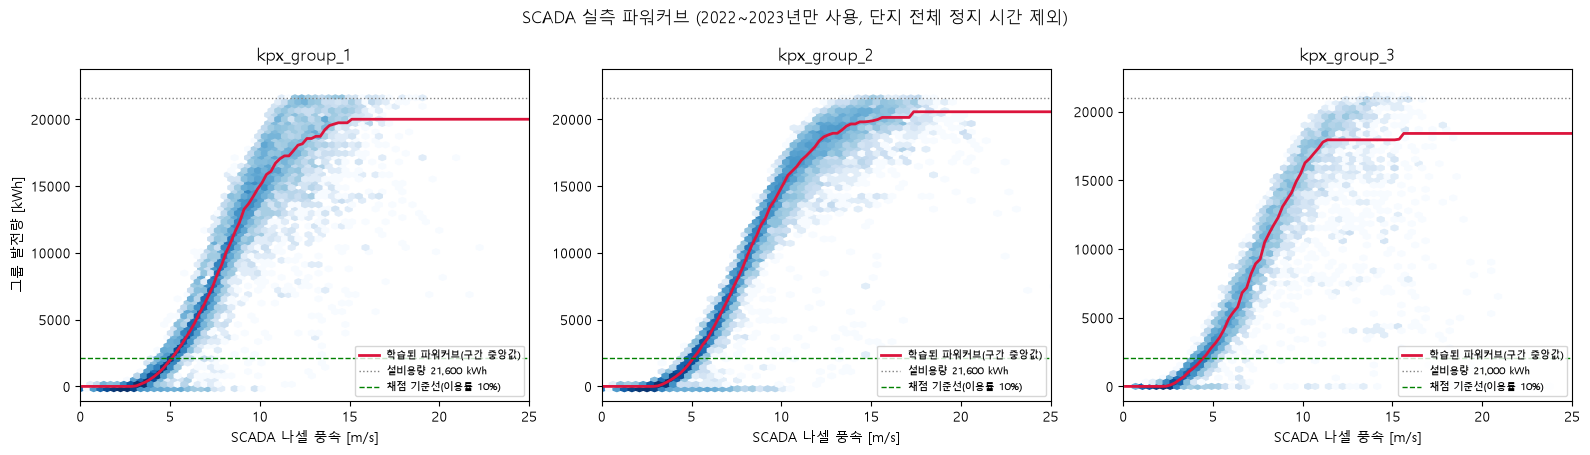

In [16]:
# 파워커브 그림: 실측 산점도 위에 학습된 곡선을 겹쳐 그린다
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6), sharey=False)
for ax, group in zip(axes, TARGET_COLS):
    cap = CAPACITY_KWH[group]
    d = scada_group[["forecast_kst_dtm", f"scada_ws_{group}", f"scada_power_{group}", f"scada_valid_{group}"]].dropna()
    in_fit = (d["forecast_kst_dtm"] >= FIT_START) & (d["forecast_kst_dtm"] <= FIT_END)
    m = in_fit & d[f"scada_valid_{group}"].astype(bool)

    ax.hexbin(d.loc[m, f"scada_ws_{group}"], d.loc[m, f"scada_power_{group}"],
              gridsize=60, mincnt=1, cmap="Blues", bins="log")
    curve = power_curves[group]
    ax.plot(curve.index, curve.values, color="crimson", lw=2, label="학습된 파워커브(구간 중앙값)")
    ax.axhline(cap, color="gray", ls=":", lw=1, label=f"설비용량 {cap:,} kWh")
    ax.axhline(cap * 0.10, color="green", ls="--", lw=1, label="채점 기준선(이용률 10%)")
    ax.set_xlim(0, 25); ax.set_ylim(-cap * 0.05, cap * 1.1)
    ax.set_xlabel("SCADA 나셀 풍속 [m/s]"); ax.set_title(group)
    ax.legend(fontsize=7, loc="lower right")
axes[0].set_ylabel("그룹 발전량 [kWh]")
fig.suptitle("SCADA 실측 파워커브 (2022~2023년만 사용, 단지 전체 정지 시간 제외)")
fig.tight_layout()
fig.savefig(FIG_DIR / "phase2_power_curve_fit.png", dpi=120)
plt.show()

### 7-5. 두 단계를 이어 붙여 "물리 예측 발전량" 피처 만들기

```
예보 풍속 3종  --(7-2 선형 보정식)-->  보정된 나셀 풍속  --(7-4 파워커브)-->  예상 발전량 [kWh]
```

이 예상 발전량(`pc_pred_*`)이 **물리+통계 하이브리드의 핵심 피처**다. 모델(Phase 3)은 이 값을 출발점으로 삼고,
결빙·난류·예보 불확실성 같은 나머지 정보로 **차이(잔차)만 보정**하면 된다. 문헌에서 순수 ML보다 안정적이라고
반복해서 보고되는 구조다 (CLAUDE.md 13번 "파워커브 하이브리드가 강함").

추가로 **밀도 보정판**도 만든다. 파워커브는 SCADA 실측이라 "그때그때의 공기 밀도"가 이미 섞여 있지만,
겨울(무거운 공기)과 여름(가벼운 공기)의 차이를 명시적으로 알려 주면 모델이 더 쉽게 배운다.
보정된 풍속에 밀도 보정을 먼저 걸고 파워커브에 넣은 값(`pc_pred_rho_*`)을 별도 컬럼으로 둔다.

세 그룹의 피처를 **모두 다 넣는다**(그룹 3 모델에도 그룹 1의 `pc_pred`가 들어간다).
그룹 1·2·3은 같은 산등성이에 있어 서로의 파워커브가 서로에게 정보가 되기 때문이다.
특히 **그룹 3은 라벨이 2023년부터만 있어 데이터가 적으므로**, 그룹 1·2에서 온 정보가 도움이 된다.

In [17]:
def add_power_curve_features(weather: pd.DataFrame) -> pd.DataFrame:
    """
    보정식 + 파워커브를 이어 붙여 '물리 예측 발전량' 피처를 만든다 (train/test 동일 적용).

    입력: weather — build_weather_features()의 출력
    출력: weather에 아래 컬럼을 추가한 새 DataFrame
        ws_hub_cal_{group}     : 예보 -> 보정된 나셀 풍속 [m/s]
        pc_pred_{group}        : 파워커브가 예측한 발전량 [kWh]
        pc_pred_rho_{group}    : 밀도 보정 풍속을 넣었을 때의 예측 발전량 [kWh]
    누수 (CLAUDE.md 4번): calib / power_curves 는 모두 2022~2023 train 구간에서만 fit된 값이다.
                          이 함수는 그 값을 '적용(transform)'만 한다.
    주의: "이용률(=pc_pred/설비용량)" 컬럼은 일부러 만들지 않는다. 설비용량은 그룹마다 고정된
          상수이므로 pc_pred를 그 상수로 나눈 값은 pc_pred와 '완전히 같은 정보'다(단순 배율).
          트리 모델이든 선형 모델이든 새 정보가 0인 중복 컬럼이며, feature importance만 둘로 갈라진다.
    """
    out = weather.copy()
    for group in TARGET_COLS:
        ws_cal = apply_wind_calibration(weather, calib[group])
        out[f"ws_hub_cal_{group}"] = ws_cal
        out[f"pc_pred_{group}"] = apply_power_curve(ws_cal, power_curves[group])

        # 공기 밀도가 표준보다 높으면(추우면) 같은 풍속이라도 더 발전한다 -> 등가 풍속을 올려서 곡선에 넣는다
        ws_cal_rho = density_corrected_ws(ws_cal, weather["rho_hub"].to_numpy())
        out[f"pc_pred_rho_{group}"] = apply_power_curve(ws_cal_rho, power_curves[group])
    return out


feat_train = add_power_curve_features(weather_train)
feat_test = add_power_curve_features(weather_test)
print("feat_train:", feat_train.shape, "| feat_test:", feat_test.shape)

# 물리 예측치가 실제 라벨을 얼마나 설명하는지 미리 확인 (모델 없이 순수 물리만으로)
print("\n[물리 예측치만으로 본 성능 — 아직 모델 학습 전]")
lab = train_merged[["forecast_kst_dtm"] + TARGET_COLS]
chk = feat_train.merge(lab, on="forecast_kst_dtm")
for group in TARGET_COLS:
    cap = CAPACITY_KWH[group]
    m = chk[group].notna() & (chk[group] >= cap * 0.10)   # 대회 채점 대상 시간만
    for col in [f"pc_pred_{group}", f"pc_pred_rho_{group}"]:
        nmae = (chk.loc[m, col] - chk.loc[m, group]).abs().mean() / cap
        corr = chk.loc[m, col].corr(chk.loc[m, group])
        print(f"  {col:>28}: NMAE {nmae:.4f}, 상관 {corr:.4f}  (n={int(m.sum()):,}, 채점 대상 시간만)")

feat_train: (26304, 125) | feat_test: (8760, 125)

[물리 예측치만으로 본 성능 — 아직 모델 학습 전]
           pc_pred_kpx_group_1: NMAE 0.1610, 상관 0.7044  (n=15,915, 채점 대상 시간만)
       pc_pred_rho_kpx_group_1: NMAE 0.1649, 상관 0.7074  (n=15,915, 채점 대상 시간만)
           pc_pred_kpx_group_2: NMAE 0.1640, 상관 0.7069  (n=15,891, 채점 대상 시간만)
       pc_pred_rho_kpx_group_2: NMAE 0.1667, 상관 0.7095  (n=15,891, 채점 대상 시간만)
           pc_pred_kpx_group_3: NMAE 0.1713, 상관 0.6589  (n=9,414, 채점 대상 시간만)
       pc_pred_rho_kpx_group_3: NMAE 0.1746, 상관 0.6558  (n=9,414, 채점 대상 시간만)


## 8. 시간축 lag/lead 피처

1-1절에서 확인했듯 **예보는 전날 13:00에 24시간치가 한꺼번에 발표**된다. 따라서 "내일 15시를 예측할 때
내일 14시·16시의 **예보값**"은 이미 손에 들어와 있는 정보다 — **누수가 아니다** (실측값이었다면 누수).

왜 도움이 되는가:

- 바람은 갑자기 생겼다 사라지지 않는다. **앞뒤 시각의 바람을 함께 보면 그 시각의 값이 튀는 오류인지 진짜 강풍인지** 구분된다.
- 바람이 **오르는 중**인지 **잦아드는 중**인지(`diff`)에 따라 같은 풍속이라도 터빈 제어(요잉·피치)가 다르게 반응한다.
- 3시간 이동 표준편차는 **그 시각 주변의 바람이 얼마나 요동치는지** = 예측이 어려운 시간대인지를 알려 준다.

lag/lead를 만들면 시계열 맨 앞·맨 뒤에 빈칸(NaN)이 생긴다. 앞뒤 가장 가까운 값으로 채운다(`bfill`/`ffill`).
이때 채워 넣는 값도 **예보값**이지 라벨이 아니므로 누수가 아니다. 영향받는 행은 각 시리즈 끝의 3행 이내다.

In [18]:
# lag/lead를 붙일 기준 컬럼: 바람의 핵심 지표와 기온
LAG_BASE_COLS = ["ldaps_ws117_mean", f"ldaps_g{BEST_CORR_LDAPS_GRID}_ws117", "gfs_ws117_mean", "t_hub_c",
                 "pc_pred_kpx_group_1"]
LAG_STEPS = [1, 2, 3]      # 몇 시간 전/후를 볼 것인가
ROLL_WINDOWS = [3, 5]      # 중심 이동창 크기(시간)


def add_lag_lead_features(feat: pd.DataFrame) -> pd.DataFrame:
    """
    예보 시계열의 앞뒤 값(lag/lead)과 이동통계를 붙인다.

    입력: feat — forecast_kst_dtm으로 정렬된 피처 표
    출력: lag/lead/diff/rolling 컬럼이 추가된 표
    누수 (CLAUDE.md 4번):
        - 대상은 전부 '예보값'이다. 예보는 전날 13:00에 다음날 24시간치가 한 번에 공개되므로
          미래 시각의 예보값도 예측 시점에 이미 알고 있다. 실측값의 lead였다면 누수다.
        - 시리즈 양 끝의 NaN은 가장 가까운 예보값으로 채운다(bfill/ffill). 라벨은 쓰지 않는다.
    """
    out = feat.sort_values("forecast_kst_dtm").reset_index(drop=True).copy()
    new = {}
    for col in LAG_BASE_COLS:
        s = out[col]
        for k in LAG_STEPS:
            new[f"{col}_lag{k}"] = s.shift(k)     # k시간 전 예보값
            new[f"{col}_lead{k}"] = s.shift(-k)   # k시간 후 예보값
        new[f"{col}_diff1"] = s.diff(1)           # 직전 시각 대비 변화량 (바람이 세지는 중? 잦아드는 중?)
        for w in ROLL_WINDOWS:
            r = s.rolling(window=w, center=True, min_periods=1)
            new[f"{col}_roll{w}_mean"] = r.mean()  # 주변 시각 평균 = 노이즈를 줄인 대표값
            new[f"{col}_roll{w}_std"] = r.std()    # 주변 시각 표준편차 = 그 시간대가 요동치는 정도
    out = pd.concat([out, pd.DataFrame(new, index=out.index)], axis=1)

    lag_cols = list(new.keys())
    n_na_before = int(out[lag_cols].isna().sum().sum())
    out[lag_cols] = out[lag_cols].bfill().ffill()
    print(f"  lag/lead 컬럼 {len(lag_cols)}개 추가, 시리즈 끝단 결측 {n_na_before}개를 인접 예보값으로 채움")
    return out


print("train:"); feat_train = add_lag_lead_features(feat_train)
print("test :"); feat_test = add_lag_lead_features(feat_test)
print("\nfeat_train:", feat_train.shape, "| feat_test:", feat_test.shape)

# 여기까지가 v1 피처 집합(179개). Phase 3·4의 실험이 이 집합 위에서 이뤄졌으므로
# 컬럼 목록을 고정해 둔다. 아래 8-B에서 추가하는 v2 피처와 구분해 저장한다.
V1_FEATURE_COLS = [c for c in feat_train.columns if c != "forecast_kst_dtm"]
print(f"v1 피처 확정: {len(V1_FEATURE_COLS)}개")

train:
  lag/lead 컬럼 55개 추가, 시리즈 끝단 결측 65개를 인접 예보값으로 채움
test :
  lag/lead 컬럼 55개 추가, 시리즈 끝단 결측 65개를 인접 예보값으로 채움

feat_train: (26304, 180) | feat_test: (8760, 180)
v1 피처 확정: 179개


## 8-B. v2 피처 추가 — 문헌 재검토로 도출한 것들

`reports/phase2_features.md` §4-5에서 "나중에 넣고 효과를 재자"고 미뤄 둔 피처들을 여기서 만든다.
Phase 4에서 **다중 시간 폴드 교차검증**을 구축했으므로, 이제 피처 하나하나의 효과를 정직하게 잴 수 있다.

**v1은 그대로 보존한다.** Phase 3·4의 모든 실험이 v1(179개) 위에서 이뤄졌으므로,
v1 컬럼 목록을 고정해 별도 파일로 저장한다. 그러면 그 노트북들을 다시 돌려도 같은 숫자가 나온다.

### 만들기 전에 확인한 것 — 원본 컬럼을 직접 재 봤다

| 확인 | 결과 | 결론 |
|---|---|---|
| `VLCDC`가 안개 지표인가 | 상대습도 ≥95%일 때 평균 **0.687**, <95%일 때 **0.025** (27배) | **훌륭한 안개·저층운 지표** |
| GFS `dswrf`가 순간값인가 | 21시(밤)에 **115 W/m²** | **평균 플럭스다. 쓰면 안 된다** |
| LDAPS `NDNSW`가 순간값인가 | 21시에 **0.0**, 12시에 487 | **순간값. 안정도 피처에 적합** |
| GFS 850hPa가 허브 조건인가 | 2m 기온과 상관 0.967, RH 상관 0.62 | 보조 추정치로는 유용 |

**Phase 2 문서의 주장 하나를 여기서 정정한다.** §4-5에서 "GFS 격자가 산을 뭉개니 850hPa를 허브 조건으로 쓰라"고 썼는데,
**LDAPS는 산을 제대로 잡는다**(격자 지형고도 997m ≈ 실제 단지 고도, `phase2_features.md` §2-3).
즉 LDAPS의 2m 기온·습도는 **이미 허브 근처 고도의 값**이다.
GFS 850hPa의 가치는 "대체재"가 아니라 **서로 다른 모델에서 온 독립적인 보조 추정치**다. 그래서 추가는 하되 기대는 낮춘다.

### 만드는 것 (4개 묶음)

| 묶음 | 피처 | 근거 |
|---|---|---|
| **① 결빙 지속성** | `icing_cum6/12/24h`, `icing_incloud_cum12h`, `hours_since_icing`, `melt_potential` | 얼음은 착빙 조건이 끝난 뒤에도 남는다 (문헌 [4][5]) |
| **② 구름·안개 착빙** | `lcc`, `mcc`, `hcc`, `vlcdc`, `icing_flag_lit`, `icing_incloud` | 착빙은 구름/안개 속에서 일어난다. 문헌 임계값 T<0°C & RH>85% [6] |
| **③ 복사 안정도** | `ndnsw`, `ndnlw`, `net_radiation`, `is_daytime`, `t850_minus_thub` | 야간 복사냉각 → 안정 경계층 → 강한 시어 |
| **④ 풍향 시어(veer)** | `ldaps_veer_10_50`, `gfs_veer_10_100`, `gfs_veer_100_850` | 높이에 따른 풍향 변화가 출력에 영향 [3][7] |

In [19]:
# ---------- 상수 (문헌 기준) ----------
# 근거: reports/phase2_features.md §4-5 [4][5][6]
ICING_LIT_T_MAX_C = 0.0     # 착빙 임계 기온: 이보다 낮아야 함 (문헌 표준: T < 0°C)
ICING_LIT_T_MIN_C = -20.0   # 이보다 추우면 공기 중 수분이 이미 얼음 결정이라 잘 안 붙는다
ICING_LIT_RH_MIN = 85.0     # 착빙 임계 상대습도 (문헌 표준: RH > 85%)
ICING_CUM_WINDOWS = [6, 12, 24]   # 착빙량 누적 창 [시간]
HOURS_SINCE_CAP = 72        # '마지막 착빙 이후 경과 시간'의 상한 [시간]. 3일이면 얼음이 남아 있을 리 없다
DAYTIME_SW_MIN = 5.0        # 순하향단파복사가 이 값보다 크면 낮 [W/m²]


def wrap_180(deg):
    """
    각도 차이를 [-180, +180) 범위로 감는다.

    왜 필요한가: 350°와 10°의 차이는 -340°가 아니라 +20°다.
    그냥 빼면 큰 값이 나와 모델이 "풍향이 크게 돌았다"고 잘못 배운다.
    출력 부호: 양수 = 높이 올라가며 시계방향으로 돎(순전, veering), 음수 = 반시계방향(역전, backing).
    """
    return (np.asarray(deg) + 180.0) % 360.0 - 180.0


def _grid_mean(df, template, grids):
    """여러 격자의 같은 변수를 평균낸다. template 예: 'ldaps_g{g}_etc_0_lcc'"""
    return np.column_stack([df[template.format(g=g)].to_numpy() for g in grids]).mean(axis=1)


def build_extra_features(df: pd.DataFrame, base: pd.DataFrame) -> pd.DataFrame:
    """
    v2 피처(구름·복사·veer·문헌 결빙 기준)를 만든다. train/test에 동일하게 적용한다.

    입력:
        df   : 01_preprocessing이 만든 merged 원본 표 (ldaps_g*, gfs_g* 컬럼)
        base : build_weather_features()의 출력 (t_hub_c, rh, icing_score 등을 재사용)
    출력:
        df와 같은 행 수의 DataFrame (forecast_kst_dtm 없음, 피처만)
    누수: 학습된 통계값을 쓰지 않는다. 각 행의 예보값만으로 계산된다 (CLAUDE.md 4번).
    """
    out = {}
    n = len(df)

    # ---------------------------------------------------------------
    # ② 구름·안개 (LDAPS는 0~1 비율, GFS는 0~100 %)
    # VLCDC = 아주 낮은 구름. 사전 확인 결과 RH>=95%일 때 평균 0.687, 미만일 때 0.025로
    # 안개·저층운을 매우 잘 구별한다 -> in-cloud icing(구름 속 착빙)의 직접 지표.
    # ---------------------------------------------------------------
    # 원본 구름량이 부동소수점 잡음으로 1.000007까지 나온다(물리적으로 0~1이어야 함). 잘라서 쓴다.
    for name, var in [("lcc", "etc_0_lcc"), ("mcc", "etc_0_mcc"),
                      ("hcc", "etc_0_hcc"), ("vlcdc", "etc_0_VLCDC")]:
        out[name] = np.clip(_grid_mean(df, "ldaps_g{g}_" + var, DENSITY_GRIDS), 0.0, 1.0)

    # 문헌 표준 착빙 조건: 기온 -20 ~ 0°C, 상대습도 85% 이상
    t_hub = base["t_hub_c"].to_numpy()
    rh = base["rh"].to_numpy()
    out["icing_flag_lit"] = ((t_hub < ICING_LIT_T_MAX_C) & (t_hub > ICING_LIT_T_MIN_C) &
                             (rh >= ICING_LIT_RH_MIN)).astype(float)
    # 구름/안개 속에 있으면서 착빙 조건 -> 과냉각 물방울에 직접 노출된다
    out["icing_incloud"] = out["icing_flag_lit"] * np.maximum(out["lcc"], out["vlcdc"])

    # ---------------------------------------------------------------
    # ③ 복사 기반 안정도
    # LDAPS NDNSW/NDNLW는 '순간값'이다(21시에 정확히 0). GFS dswrf는 예보 시작 이후 평균이라
    # 밤에도 0이 아니므로(21시에 115 W/m²) 쓰지 않는다.
    # ---------------------------------------------------------------
    ndnsw = _grid_mean(df, "ldaps_g{g}_surface_0_NDNSW", DENSITY_GRIDS)   # 순 하향 단파복사 [W/m²]
    ndnlw = _grid_mean(df, "ldaps_g{g}_surface_0_NDNLW", DENSITY_GRIDS)   # 순 하향 장파복사 [W/m²], 보통 음수(냉각)
    out["ndnsw"] = ndnsw
    out["ndnlw"] = ndnlw
    # 순복사 = 지면이 얻는 에너지. 음수면 지면이 식는다 -> 안정 경계층 -> 위아래가 안 섞여 시어가 커진다
    out["net_radiation"] = ndnsw + ndnlw
    out["is_daytime"] = (ndnsw > DAYTIME_SW_MIN).astype(float)

    # 850hPa(해발 약 1,500m)와 허브(약 1,120m)의 기온차.
    # 위가 더 따뜻하면(양수) 역전층 = 매우 안정 = 난류가 거의 없다.
    out["gfs_r850"] = _grid_mean(df, "gfs_g{g}_isobaricInhPa_850_r", GFS_REP_GRIDS)
    out["t850_minus_thub"] = base["t850_c"].to_numpy() - t_hub

    # ---------------------------------------------------------------
    # ④ 풍향 시어(veer): 높이에 따라 풍향이 얼마나 돌아가는가
    # 근거: reports/phase2_features.md §4-5 [3][7]. 순전(양수)은 출력을 약간 늘리고 역전(음수)은 줄인다.
    # ---------------------------------------------------------------
    ld = {g: ldaps_grid_wind(df, g) for g in LDAPS_REP_GRIDS}
    gf = {g: gfs_grid_wind(df, g) for g in GFS_REP_GRIDS}

    out["ldaps_veer_10_50"] = np.column_stack(
        [wrap_180(ld[g]["wd50"] - ld[g]["wd10"]) for g in LDAPS_REP_GRIDS]).mean(axis=1)
    out["gfs_veer_10_100"] = np.column_stack(
        [wrap_180(gf[g]["wd100"] - gf[g]["wd10"]) for g in GFS_REP_GRIDS]).mean(axis=1)
    out["gfs_veer_100_850"] = np.column_stack(
        [wrap_180(gf[g]["wd850"] - gf[g]["wd100"]) for g in GFS_REP_GRIDS]).mean(axis=1)

    extra = pd.DataFrame(out)
    assert len(extra) == n
    return extra


extra_train = build_extra_features(train_merged, weather_train)
extra_test = build_extra_features(test_merged, weather_test)
print("extra_train:", extra_train.shape, "| extra_test:", extra_test.shape)
print("결측:", int(extra_train.isna().sum().sum()), int(extra_test.isna().sum().sum()))

# 눈으로 확인: 문헌 기준 결빙 플래그가 겨울에 몰리는가
_chk = pd.DataFrame({"month": train_merged["forecast_kst_dtm"].dt.month,
                     "icing_lit": extra_train["icing_flag_lit"],
                     "icing_incloud": extra_train["icing_incloud"]})
print("\n월별 문헌기준 착빙 조건 비율(%):")
print((_chk.groupby("month")["icing_lit"].mean() * 100).round(1).to_string())

extra_train: (26304, 15) | extra_test: (8760, 15)
결측: 0 0

월별 문헌기준 착빙 조건 비율(%):
month
1     34.9
2     41.2
3     17.5
4      3.2
5      0.1
6      0.0
7      0.0
8      0.0
9      0.0
10     0.3
11    11.3
12    32.3


### 8-B-1. 결빙 지속성 — 이 노트북에서 가장 중요한 v2 피처

문헌의 핵심 지적은 임계값이 아니라 **시간 구조**였다 (`reports/phase2_features.md` §4-5).

> 관측된 결빙 사건은 **4일 중 30시간 지속**되고, 날개 끝 얼음이 0.3m까지 쌓인다.
> ISO 12494 용어로 **기상학적 착빙**(조건이 성립 중)과 **기구적 착빙**(얼음이 실제로 붙어 있음)은 다르다.
> **발전 손실을 만드는 것은 후자다.**

즉 **얼음은 착빙 조건이 끝난 뒤에도 날개에 남아 있다.**
v1의 `icing_score`는 **그 시각의 조건만** 본다. 밤새 얼음이 얼고 아침에 기온이 올라 조건이 해제되면
v1 피처는 0을 내놓지만 실제 날개에는 얼음이 그대로 있다. **구조적 결함이었다.**

**만드는 것**

| 피처 | 계산 | 뜻 |
|---|---|---|
| `icing_cum6/12/24h` | 과거 6/12/24시간 `icing_score`의 **누적합** | 쌓인 얼음의 양 |
| `icing_incloud_cum12h` | 과거 12시간 `icing_incloud`의 누적합 | 구름 속 착빙 누적 |
| `hours_since_icing` | 마지막 착빙 조건 이후 경과 시간 (최대 72) | 얼음이 남아 있을 가능성 |
| `melt_potential` | `max(기온, 0) × icing_cum24h` | 얼음이 쌓였는데 기온이 올라감 = 해빙·탈락 |

**누수 검토 (CLAUDE.md 4번)** — 세 가지를 따져야 한다.

1. **과거 방향(trailing)만 본다.** 미래 시각의 값을 끌어오지 않는다.
2. **예보값만 쓴다.** 라벨(발전량)이나 실측(SCADA)을 전혀 참조하지 않는다.
3. **train과 test를 시간순으로 이어 붙여 계산한다.** test의 첫 시각(2025-01-01 01:00)의 24시간 누적은
   2024년 12월 31일 예보값을 참조하는데, 그 예보는 **2024-12-30 13:00에 이미 공개**된 것이다.
   예측기준시점(2024-12-31 13:00) 이전이므로 사용 가능하다.
   만약 이어 붙이지 않고 test만 따로 계산하면 test 첫 24시간의 누적값이 잘못된다(과거가 없어서).
   **이어 붙이는 쪽이 누수가 아니라 더 정확하다.**

In [20]:
def add_icing_persistence(feat_concat: pd.DataFrame) -> pd.DataFrame:
    """
    결빙의 '시간 구조'(누적·경과·해빙)를 나타내는 피처를 붙인다.

    입력: feat_concat -- train과 test를 시간순으로 이어 붙인 표.
                        icing_score, icing_incloud, icing_flag_lit, t_hub_c 컬럼 필요.
    출력: 위 표에 결빙 지속성 컬럼이 추가된 새 표.

    누수 (CLAUDE.md 4번):
        - rolling(w)은 기본이 '과거 방향'이다. 미래 값을 보지 않는다.
        - 사용하는 값은 전부 예보값이다. 라벨/SCADA를 참조하지 않는다.
        - train/test를 이어 붙이는 이유: test 첫 시각의 24시간 누적이 2024년 말 예보를 참조해야 하는데,
          그 예보는 예측기준시점 이전에 이미 공개된 것이므로 사용 가능하다.
    """
    out = feat_concat.sort_values("forecast_kst_dtm").reset_index(drop=True).copy()

    # 착빙량 프록시: 과거 w시간 동안 착빙 조건이 얼마나 강하게 지속됐는가
    for w in ICING_CUM_WINDOWS:
        out[f"icing_cum{w}h"] = out["icing_score"].rolling(w, min_periods=1).sum()
    out["icing_incloud_cum12h"] = out["icing_incloud"].rolling(12, min_periods=1).sum()

    # 마지막 착빙 조건 이후 몇 시간이 지났는가 (얼음이 남아 있을 가능성의 역지표)
    flag = out["icing_flag_lit"].to_numpy()
    hours_since = np.empty(len(flag), dtype=float)
    counter = HOURS_SINCE_CAP          # 시리즈 시작 시점: 최근 착빙이 없었다고 가정
    for i, f in enumerate(flag):
        counter = 0.0 if f > 0 else min(counter + 1.0, HOURS_SINCE_CAP)
        hours_since[i] = counter
    out["hours_since_icing"] = hours_since

    # 해빙 가능성: 얼음이 쌓여 있는데(cum24h가 큼) 기온이 0°C 위로 올라감
    out["melt_potential"] = np.clip(out["t_hub_c"].to_numpy(), 0.0, None) * out["icing_cum24h"].to_numpy()
    return out


# extra_*는 원본(train_merged/test_merged)의 행 순서로 만들어졌고, feat_*는 lag/lead 단계에서
# 시간순 정렬 후 인덱스를 초기화했다. 두 표의 시각이 정확히 같은 순서인지 먼저 확인한다.
assert np.array_equal(feat_train["forecast_kst_dtm"].to_numpy(), train_merged["forecast_kst_dtm"].to_numpy())
assert np.array_equal(feat_test["forecast_kst_dtm"].to_numpy(), test_merged["forecast_kst_dtm"].to_numpy())

# train과 test를 시간순으로 이어 붙여 계산한 뒤 다시 나눈다
v2_train = pd.concat([feat_train, extra_train], axis=1)
v2_test = pd.concat([feat_test, extra_test], axis=1)
v2_train["_split"] = "train"; v2_test["_split"] = "test"

_concat = pd.concat([v2_train, v2_test], ignore_index=True)
assert _concat["forecast_kst_dtm"].is_monotonic_increasing, "train과 test가 시간순으로 이어지지 않습니다"
_concat = add_icing_persistence(_concat)

v2_train = _concat[_concat["_split"] == "train"].drop(columns=["_split"]).reset_index(drop=True)
v2_test = _concat[_concat["_split"] == "test"].drop(columns=["_split"]).reset_index(drop=True)

V2_ADDED_COLS = [c for c in v2_train.columns if c not in V1_FEATURE_COLS and c != "forecast_kst_dtm"]
print(f"v2 추가 피처 {len(V2_ADDED_COLS)}개: {V2_ADDED_COLS}")
print(f"\nv2_train: {v2_train.shape} | v2_test: {v2_test.shape}")
print("결측:", int(v2_train[V2_ADDED_COLS].isna().sum().sum()), int(v2_test[V2_ADDED_COLS].isna().sum().sum()))

v2 추가 피처 21개: ['lcc', 'mcc', 'hcc', 'vlcdc', 'icing_flag_lit', 'icing_incloud', 'ndnsw', 'ndnlw', 'net_radiation', 'is_daytime', 'gfs_r850', 't850_minus_thub', 'ldaps_veer_10_50', 'gfs_veer_10_100', 'gfs_veer_100_850', 'icing_cum6h', 'icing_cum12h', 'icing_cum24h', 'icing_incloud_cum12h', 'hours_since_icing', 'melt_potential']

v2_train: (26304, 201) | v2_test: (8760, 201)
결측: 0 0


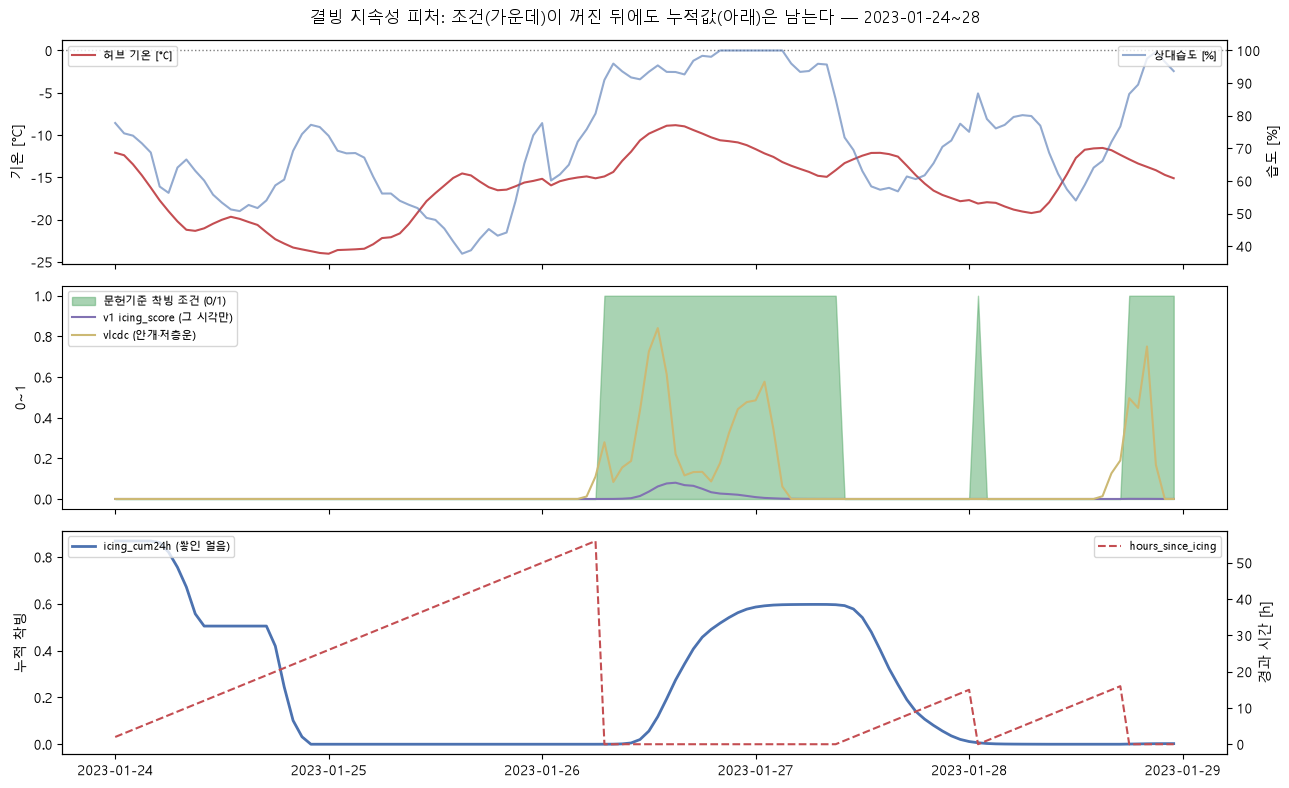

In [21]:
# 결빙 지속성이 실제로 '조건이 끝난 뒤에도 남는' 신호를 만드는지 눈으로 확인한다.
# 착빙 조건이 강했던 겨울 사례 하나를 골라 시계열로 그린다.
_win = v2_train[(v2_train["forecast_kst_dtm"] >= "2023-01-24") &
                (v2_train["forecast_kst_dtm"] < "2023-01-29")].set_index("forecast_kst_dtm")

fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)
axes[0].plot(_win.index, _win["t_hub_c"], color="#C44E52", label="허브 기온 [°C]")
axes[0].axhline(0, color="gray", ls=":", lw=1)
ax0b = axes[0].twinx(); ax0b.plot(_win.index, _win["rh"], color="#4C72B0", alpha=0.6, label="상대습도 [%]")
axes[0].set_ylabel("기온 [°C]"); ax0b.set_ylabel("습도 [%]")
axes[0].legend(loc="upper left", fontsize=8); ax0b.legend(loc="upper right", fontsize=8)

axes[1].fill_between(_win.index, _win["icing_flag_lit"], color="#55A868", alpha=0.5, label="문헌기준 착빙 조건 (0/1)")
axes[1].plot(_win.index, _win["icing_score"], color="#8172B2", label="v1 icing_score (그 시각만)")
axes[1].plot(_win.index, _win["vlcdc"], color="#CCB974", label="vlcdc (안개·저층운)")
axes[1].legend(fontsize=8); axes[1].set_ylabel("0~1")

axes[2].plot(_win.index, _win["icing_cum24h"], color="#4C72B0", lw=2, label="icing_cum24h (쌓인 얼음)")
ax2b = axes[2].twinx()
ax2b.plot(_win.index, _win["hours_since_icing"], color="#C44E52", ls="--", label="hours_since_icing")
axes[2].set_ylabel("누적 착빙"); ax2b.set_ylabel("경과 시간 [h]")
axes[2].legend(loc="upper left", fontsize=8); ax2b.legend(loc="upper right", fontsize=8)

fig.suptitle("결빙 지속성 피처: 조건(가운데)이 꺼진 뒤에도 누적값(아래)은 남는다 — 2023-01-24~28")
fig.tight_layout(); fig.savefig(FIG_DIR / "phase2b_icing_persistence.png", dpi=120); plt.show()

### 8-B-2. v2 피처가 라벨과 상관이 있는가 (거친 사전 점검)

**주의**: 상관이 낮다고 쓸모없는 피처가 아니다. 결빙 피처는 **겨울의 일부 시간에만** 작동하므로
전체 상관은 낮게 나오는 것이 정상이다. 실제 판정은 `06_feature_ablation.ipynb`에서
**다중 폴드 교차검증으로 total_score 변화를 재서** 한다. 여기서는 값이 상식적인지만 본다.

In [22]:
_lab = train_merged[['forecast_kst_dtm'] + TARGET_COLS]
_chk = v2_train.merge(_lab, on='forecast_kst_dtm', how='left')

rows = []
for c in V2_ADDED_COLS:
    r = {'피처': c}
    for g in TARGET_COLS:
        cap = CAPACITY_KWH[g]
        m = _chk[g].notna() & (_chk[g] >= cap * 0.10)     # 채점 대상 시간만
        r[g[-1]] = _chk.loc[m, c].corr(_chk.loc[m, g])
    rows.append(r)
corr_v2 = pd.DataFrame(rows).set_index('피처')
corr_v2['평균|r|'] = corr_v2.abs().mean(axis=1)
print('[v2 피처와 발전량의 상관 — 채점 대상 시간만]')
print(corr_v2.sort_values('평균|r|', ascending=False).to_string(float_format=lambda x: f'{x:+.4f}'))

# 겨울(12~2월)만 따로: 결빙 피처는 겨울에만 의미가 있다
_win_m = _chk['forecast_kst_dtm'].dt.month.isin([12, 1, 2])
print('\n[겨울(12~2월)만 — 결빙 계열 피처]')
icing_cols = [c for c in V2_ADDED_COLS if 'icing' in c or c in ('vlcdc', 'lcc', 'melt_potential', 'hours_since_icing')]
rows = []
for c in icing_cols:
    r = {'피처': c}
    for g in TARGET_COLS:
        cap = CAPACITY_KWH[g]
        m = _win_m & _chk[g].notna() & (_chk[g] >= cap * 0.10)
        r[g[-1]] = _chk.loc[m, c].corr(_chk.loc[m, g])
    rows.append(r)
print(pd.DataFrame(rows).set_index('피처').to_string(float_format=lambda x: f'{x:+.4f}'))

[v2 피처와 발전량의 상관 — 채점 대상 시간만]
                           1       2       3   평균|r|
피처                                                  
t850_minus_thub      +0.3591 +0.3285 +0.2799 +0.3225
hours_since_icing    -0.2437 -0.2268 -0.1933 +0.2213
gfs_r850             -0.2091 -0.1646 -0.0923 +0.1553
net_radiation        -0.1590 -0.1588 -0.1415 +0.1531
mcc                  -0.1842 -0.1379 -0.1262 +0.1494
icing_flag_lit       +0.1546 +0.1562 +0.1279 +0.1462
ndnsw                -0.1355 -0.1443 -0.1410 +0.1403
icing_incloud        +0.1286 +0.1264 +0.1153 +0.1234
is_daytime           -0.1261 -0.1287 -0.1071 +0.1206
icing_incloud_cum12h +0.1218 +0.1120 +0.0950 +0.1096
hcc                  -0.1323 -0.0824 -0.0580 +0.0909
icing_cum6h          +0.0882 +0.0838 +0.0734 +0.0818
icing_cum12h         +0.0781 +0.0653 +0.0539 +0.0658
icing_cum24h         +0.0789 +0.0556 +0.0468 +0.0604
ndnlw                -0.0597 -0.0144 +0.0455 +0.0399
lcc                  -0.0153 +0.0189 +0.0809 +0.0384
vlcdc            

## 9. 최종 검증 — 저장 전에 반드시 통과해야 할 항목

피처 표가 조용히 망가지면 이후 모든 실험이 무의미해진다. 저장 직전에 아래를 코드로 강제 확인한다.

1. **행 수**: train 26,304 / test 8,760
2. **컬럼 일치**: train과 test의 피처 컬럼이 이름·순서까지 완전히 같은가 (라벨 3개는 train에만)
3. **결측·무한대 없음**
4. **시간 정렬·중복 없음**
5. **값 범위 상식성**: 풍속 ≥ 0, 파워커브 예측치가 [0, 설비용량] 범위 안
6. **누수 점검**: 피처 이름 중 `scada_`로 시작하는 것이 하나도 없어야 한다 (실측치가 그대로 들어가면 test에 없다)

In [23]:
FEATURE_COLS = V1_FEATURE_COLS + V2_ADDED_COLS     # v2 = v1 + 추가분

def validate_feature_frame(name, f, cols):
    """피처 표가 저장해도 되는 상태인지 강제 확인한다. 하나라도 어긋나면 AssertionError."""
    n_expected = N_TRAIN_HOURS if name == "train" else N_TEST_HOURS
    assert len(f) == n_expected, f"{name} 행 수 이상: {len(f)}"

    n_na = int(f[cols].isna().sum().sum())
    n_inf = int(np.isinf(f[cols].to_numpy()).sum())
    assert n_na == 0, f"{name} 결측 {n_na}개"
    assert n_inf == 0, f"{name} 무한대 {n_inf}개"

    assert f["forecast_kst_dtm"].is_monotonic_increasing, f"{name} 시간 정렬 안 됨"
    assert not f["forecast_kst_dtm"].duplicated().any(), f"{name} 시각 중복"

    # 풍속류는 음수가 될 수 없다 (sin/cos/차분/표준편차/veer는 음수가 정상이라 제외)
    ws_cols = [c for c in cols if "ws" in c and not any(k in c for k in
               ("sin", "cos", "diff", "std", "veer"))]
    for c in ws_cols:
        assert f[c].min() >= -1e-9, f"{name} {c} 에 음수 풍속"

    for group in TARGET_COLS:
        cap = CAPACITY_KWH[group]
        for c in [f"pc_pred_{group}", f"pc_pred_rho_{group}"]:
            assert f[c].between(-1e-6, cap + 1e-6).all(), f"{name} {c} 범위 이탈"

    # 누수 점검: SCADA 실측치나 라벨이 피처에 섞이면 test에서 재현할 수 없다
    leaked = [c for c in cols if c.startswith("scada_")]
    assert not leaked, f"SCADA 실측 컬럼이 피처에 들어 있습니다: {leaked}"
    assert not any(c in TARGET_COLS for c in cols), "라벨이 피처에 들어 있습니다"


# v1(179개)과 v2(v1 + 추가분)를 각각 검증한다
assert list(feat_train.columns) == list(feat_test.columns), "v1 train/test 컬럼이 다릅니다"
assert list(v2_train.columns) == list(v2_test.columns), "v2 train/test 컬럼이 다릅니다"

validate_feature_frame("train", feat_train, V1_FEATURE_COLS)
validate_feature_frame("test", feat_test, V1_FEATURE_COLS)
validate_feature_frame("train", v2_train, FEATURE_COLS)
validate_feature_frame("test", v2_test, FEATURE_COLS)

# v1 컬럼이 v2 안에서 값까지 완전히 동일한지 (v2를 만들며 v1을 건드리지 않았는가)
for c in V1_FEATURE_COLS:
    assert np.array_equal(feat_train[c].to_numpy(), v2_train[c].to_numpy()), f"v2가 v1 컬럼 {c}를 바꿨습니다"

# 결빙 지속성 피처의 값 범위가 상식적인가
assert v2_train["hours_since_icing"].between(0, HOURS_SINCE_CAP).all()
assert (v2_train["icing_cum24h"] >= 0).all() and (v2_train["melt_potential"] >= 0).all()
_cloud = v2_train[["lcc", "mcc", "hcc", "vlcdc"]]
assert (_cloud >= 0).all().all() and (_cloud <= 1).all().all(), "구름량은 0~1 이어야 합니다"
_veer = v2_train[["ldaps_veer_10_50", "gfs_veer_10_100", "gfs_veer_100_850"]]
assert (_veer >= -180).all().all() and (_veer < 180).all().all(), "veer는 [-180,180) 이어야 합니다"

print(f"검증 통과 ✔")
print(f"  v1 피처 {len(V1_FEATURE_COLS)}개 | v2 추가 {len(V2_ADDED_COLS)}개 -> v2 총 {len(FEATURE_COLS)}개")
print(f"  v1: train {feat_train.shape}, test {feat_test.shape}")
print(f"  v2: train {v2_train.shape}, test {v2_test.shape}")
print(f"  SCADA fit 기간: {FIT_START.date()} ~ {FIT_END.date()} (2024년 홀드아웃 미사용)")

검증 통과 ✔
  v1 피처 179개 | v2 추가 21개 -> v2 총 200개
  v1: train (26304, 180), test (8760, 180)
  v2: train (26304, 201), test (8760, 201)
  SCADA fit 기간: 2022-01-01 ~ 2024-01-01 (2024년 홀드아웃 미사용)


## 10. 피처 ↔ 라벨 상관 확인 (v1 기준)

만든 피처가 실제로 발전량을 설명하는지 대략 확인한다. 대회 채점은 **이용률 10% 이상 시간만** 대상이므로,
상관도 그 구간에서 계산해야 의미가 있다(저풍속 구간을 포함하면 상관이 부풀려 보인다).

이 표는 Phase 3(모델 선택)에서 feature importance와 비교할 기준선이므로 **v1 피처만** 대상으로 한다
(v2 피처의 상관은 §8-B-2에서 따로 봤다).

[라벨과 절대상관이 높은 피처 상위 20개 — 채점 대상 시간(이용률≥10%)만]
                                kpx_group_1  kpx_group_2  kpx_group_3     평균
pc_pred_kpx_group_1_roll5_mean       0.7179       0.7195       0.6727 0.7034
pc_pred_kpx_group_1_roll3_mean       0.7132       0.7143       0.6669 0.6981
pc_pred_kpx_group_1_lead1            0.7073       0.7116       0.6650 0.6946
pc_pred_rho_kpx_group_2              0.7111       0.7095       0.6561 0.6922
pc_pred_kpx_group_3                  0.7082       0.7066       0.6589 0.6912
pc_pred_rho_kpx_group_3              0.7096       0.7059       0.6558 0.6904
pc_pred_kpx_group_2                  0.7061       0.7069       0.6553 0.6894
pc_pred_rho_kpx_group_1              0.7074       0.7055       0.6549 0.6893
pc_pred_kpx_group_1                  0.7044       0.7052       0.6567 0.6887
pc_pred_kpx_group_1_lead2            0.6968       0.7054       0.6591 0.6871
ldaps_g13_ws117_roll5_mean           0.6874       0.6905       0.6398 0.6726
pc_pred_kpx_group_1_lead3     

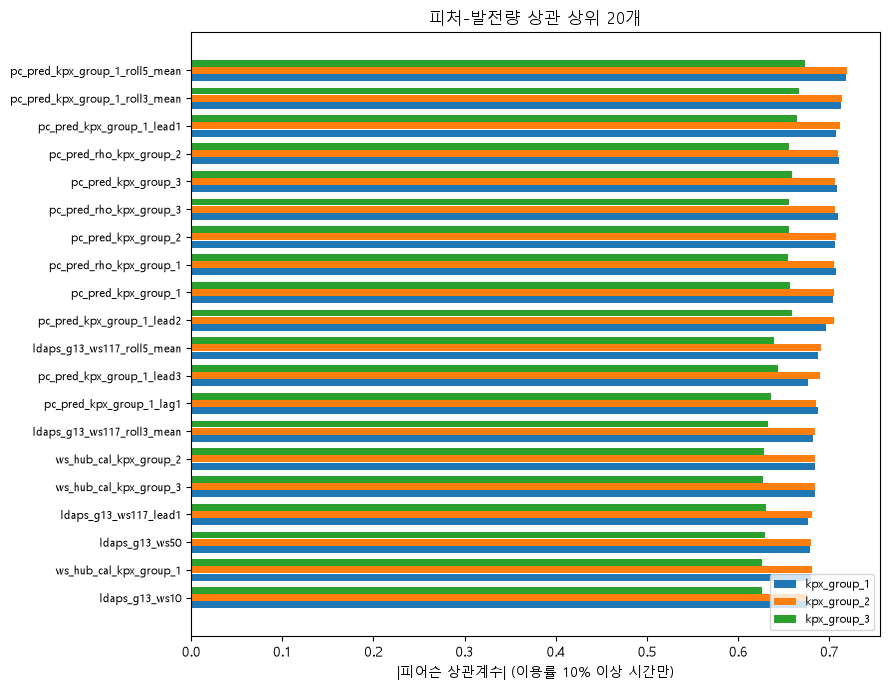

In [24]:
labeled = feat_train.merge(train_merged[["forecast_kst_dtm"] + TARGET_COLS], on="forecast_kst_dtm", how="left")

corr_rows = []
for group in TARGET_COLS:
    cap = CAPACITY_KWH[group]
    m = labeled[group].notna() & (labeled[group] >= cap * 0.10)   # 채점 대상 시간만
    c = labeled.loc[m, V1_FEATURE_COLS].corrwith(labeled.loc[m, group]).abs().sort_values(ascending=False)
    corr_rows.append(c.rename(group))
corr_tbl = pd.concat(corr_rows, axis=1)
corr_tbl["평균"] = corr_tbl.mean(axis=1)

print("[라벨과 절대상관이 높은 피처 상위 20개 — 채점 대상 시간(이용률≥10%)만]")
print(corr_tbl.sort_values("평균", ascending=False).head(20).to_string(float_format=lambda x: f"{x:.4f}"))

top = corr_tbl.sort_values("평균", ascending=False).head(20).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 7))
y = np.arange(len(top))
for i, group in enumerate(TARGET_COLS):
    ax.barh(y + (i - 1) * 0.26, top[group], height=0.25, label=group)
ax.set_yticks(y); ax.set_yticklabels(top.index, fontsize=8)
ax.set_xlabel("|피어슨 상관계수| (이용률 10% 이상 시간만)")
ax.legend(fontsize=8); ax.set_title("피처-발전량 상관 상위 20개")
fig.tight_layout()
fig.savefig(FIG_DIR / "phase2_feature_target_corr.png", dpi=120)
plt.show()

## 11. 캐시 저장

다음 노트북들이 바로 읽을 수 있도록 parquet으로 저장한다. **두 벌을 저장한다.**

| 파일 | 내용 | 왜 |
|---|---|---|
| `features_train.parquet` / `features_test.parquet` | **v1 (179개)** | Phase 3·4의 모든 실험이 이 집합 위에서 이뤄졌다. 그대로 두어야 그 노트북들을 다시 돌려도 같은 숫자가 나온다 |
| `features_v2_train.parquet` / `features_v2_test.parquet` | **v2 (v1 + 추가분)** | `06_feature_ablation.ipynb`가 v1 대비 효과를 잰다 |
| `feature_manifest.json` | 두 집합의 컬럼 목록과 v2 묶음별 분류 | 어떤 피처가 어느 묶음인지 코드로 조회할 수 있게 |

train 파일에는 라벨 3개를 함께 넣는다 (라벨은 그대로 NaN 유지 — 그룹 3의 2022년은 결측이지 0이 아니다).

**주의**: `data/`는 `.gitignore` 대상이라 이 파일들은 커밋되지 않는다. 다른 PC에서 재현하려면
`01_preprocessing.ipynb` → `03_features.ipynb` 순으로 다시 실행하면 된다 (둘 다 Restart & Run All로 동작).

SCADA에서 학습한 값(보정계수, 파워커브)은 `models/phase2_scada_fit.npz`에 함께 저장한다.
`train.ipynb`/`inference.ipynb`가 동일한 값을 쓰도록 보장하기 위해서다 (CLAUDE.md 12번 재현성).

In [25]:
import json

MODELS_DIR = Path("models")
MODELS_DIR.mkdir(exist_ok=True)

label_cols = ["forecast_kst_dtm"] + TARGET_COLS

# v1: Phase 3·4가 쓰는 집합 (건드리지 않는다)
feat_train_out = feat_train.merge(train_merged[label_cols], on="forecast_kst_dtm", how="left")
feat_train_out.to_parquet(PROCESSED_DIR / "features_train.parquet", index=False)
feat_test.to_parquet(PROCESSED_DIR / "features_test.parquet", index=False)

# v2: v1 + 이번에 추가한 피처
v2_train_out = v2_train.merge(train_merged[label_cols], on="forecast_kst_dtm", how="left")
v2_train_out.to_parquet(PROCESSED_DIR / "features_v2_train.parquet", index=False)
v2_test.to_parquet(PROCESSED_DIR / "features_v2_test.parquet", index=False)

# 피처 묶음 정의: 06_feature_ablation.ipynb가 묶음 단위로 효과를 잰다
V2_BLOCKS = {
    "icing_persistence": [f"icing_cum{w}h" for w in ICING_CUM_WINDOWS] +
                         ["icing_incloud_cum12h", "hours_since_icing", "melt_potential"],
    "cloud_fog_icing": ["lcc", "mcc", "hcc", "vlcdc", "icing_flag_lit", "icing_incloud"],
    "radiation_stability": ["ndnsw", "ndnlw", "net_radiation", "is_daytime", "gfs_r850", "t850_minus_thub"],
    "veer": ["ldaps_veer_10_50", "gfs_veer_10_100", "gfs_veer_100_850"],
}
assert sorted(sum(V2_BLOCKS.values(), [])) == sorted(V2_ADDED_COLS), "묶음 정의가 추가 피처 목록과 다릅니다"

manifest = {
    "v1_features": V1_FEATURE_COLS,
    "v2_added_features": V2_ADDED_COLS,
    "v2_blocks": V2_BLOCKS,
    "target_cols": TARGET_COLS,
    "scada_fit_start": str(FIT_START), "scada_fit_end": str(FIT_END),
}
with open(PROCESSED_DIR / "feature_manifest.json", "w", encoding="utf-8") as fp:
    json.dump(manifest, fp, ensure_ascii=False, indent=2)

# SCADA로 학습한 계수·곡선을 저장 (train/inference가 같은 값을 쓰도록)
np.savez(
    MODELS_DIR / "phase2_scada_fit.npz",
    calib_group_1=calib["kpx_group_1"], calib_group_2=calib["kpx_group_2"], calib_group_3=calib["kpx_group_3"],
    curve_ws=power_curves["kpx_group_1"].index.to_numpy(),
    curve_group_1=power_curves["kpx_group_1"].to_numpy(),
    curve_group_2=power_curves["kpx_group_2"].to_numpy(),
    curve_group_3=power_curves["kpx_group_3"].to_numpy(),
    cal_predictors=np.array(CAL_PREDICTORS, dtype=object),
    fit_start=str(FIT_START), fit_end=str(FIT_END),
)

for p in ["features_train.parquet", "features_test.parquet",
          "features_v2_train.parquet", "features_v2_test.parquet", "feature_manifest.json"]:
    fp = PROCESSED_DIR / p
    print(f"저장 완료: {fp} ({fp.stat().st_size / 1e6:.1f} MB)")
print(f"저장 완료: {MODELS_DIR / 'phase2_scada_fit.npz'}")

print(f"\nv1 {len(V1_FEATURE_COLS)}개 -> v2 {len(FEATURE_COLS)}개 (추가 {len(V2_ADDED_COLS)}개)")
for k, v in V2_BLOCKS.items():
    print(f"  {k:<22}: {len(v)}개")
print("라벨 결측(그대로 유지): " + ", ".join(f"{g}={int(v2_train_out[g].isna().sum())}" for g in TARGET_COLS))

저장 완료: data\processed\features_train.parquet (42.6 MB)
저장 완료: data\processed\features_test.parquet (14.1 MB)
저장 완료: data\processed\features_v2_train.parquet (45.5 MB)
저장 완료: data\processed\features_v2_test.parquet (15.1 MB)
저장 완료: data\processed\feature_manifest.json (0.0 MB)
저장 완료: models\phase2_scada_fit.npz

v1 179개 -> v2 200개 (추가 21개)
  icing_persistence     : 6개
  cloud_fog_icing       : 6개
  radiation_stability   : 6개
  veer                  : 3개
라벨 결측(그대로 유지): kpx_group_1=104, kpx_group_2=103, kpx_group_3=8766


In [26]:
# 저장한 파일을 다시 읽어 무결성 확인 (Restart & Run All 재현성 점검)
_t = pd.read_parquet(PROCESSED_DIR / "features_train.parquet")
_e = pd.read_parquet(PROCESSED_DIR / "features_test.parquet")
_t2 = pd.read_parquet(PROCESSED_DIR / "features_v2_train.parquet")
_e2 = pd.read_parquet(PROCESSED_DIR / "features_v2_test.parquet")

assert _t.shape == feat_train_out.shape and _e.shape == feat_test.shape
assert _t2.shape == v2_train_out.shape and _e2.shape == v2_test.shape
assert set(_e.columns) | set(TARGET_COLS) == set(_t.columns)
assert set(_e2.columns) | set(TARGET_COLS) == set(_t2.columns)
# v1 파일의 컬럼이 v2 파일 안에 값까지 그대로 들어 있는지
for c in V1_FEATURE_COLS:
    assert np.array_equal(_t[c].to_numpy(), _t2[c].to_numpy()), f"v1과 v2의 {c} 값이 다릅니다"

print("재로딩 확인 ✔")
print("v1 train:", _t.shape, "| v1 test:", _e.shape)
print("v2 train:", _t2.shape, "| v2 test:", _e2.shape)
print("기간:", _t["forecast_kst_dtm"].min(), "~", _e["forecast_kst_dtm"].max())

재로딩 확인 ✔
v1 train: (26304, 183) | v1 test: (8760, 180)
v2 train: (26304, 204) | v2 test: (8760, 201)
기간: 2022-01-01 01:00:00 ~ 2026-01-01 00:00:00
